In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))

from scripts.utils import load_analysis_df
from scripts.multivariate_analysis import (
    multivariate_pivot_heatmap,
    multivariate_grouped_boxplot,
    multivariate_facet_scatter,
    multivariate_pairplot,
    multivariate_amenity_profile,
)

df = load_analysis_df()
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")


[OK] Loaded analysis DataFrame ← c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\data\cleaned_and_processed_data.parquet  (953 rows × 32 cols)
Loaded: 953 rows × 32 columns


Pivot Heatmap — Median Price by Country × Theme
Theme        Adventure  Beach  General  Historic  Luxury  Nature  Romantic  Urban
Country                                                                          
Canada           127.5  305.0    135.0     154.0   335.0   126.0     271.0  163.0
Indonesia        111.0  186.0    166.0     154.0   207.5   140.5     184.0    NaN
Italy              NaN   25.0    105.0      75.0     NaN    80.5     148.0    NaN
Mexico             NaN   55.0     89.0      42.0   138.0   141.0     112.0   57.5
Philippines      128.0  316.0     45.0       NaN     NaN    56.5      26.0   35.0
Thailand           NaN   90.0     71.0       NaN    64.0    53.0      45.0   58.0
US               239.0  252.0    167.0     185.0   226.0   184.0     247.0   95.5
Unknown          155.0  181.0    181.0     182.5   184.0   178.0     171.0  129.0

  Grand median : 154.00
  Overall range  : 25.00 → 335.00


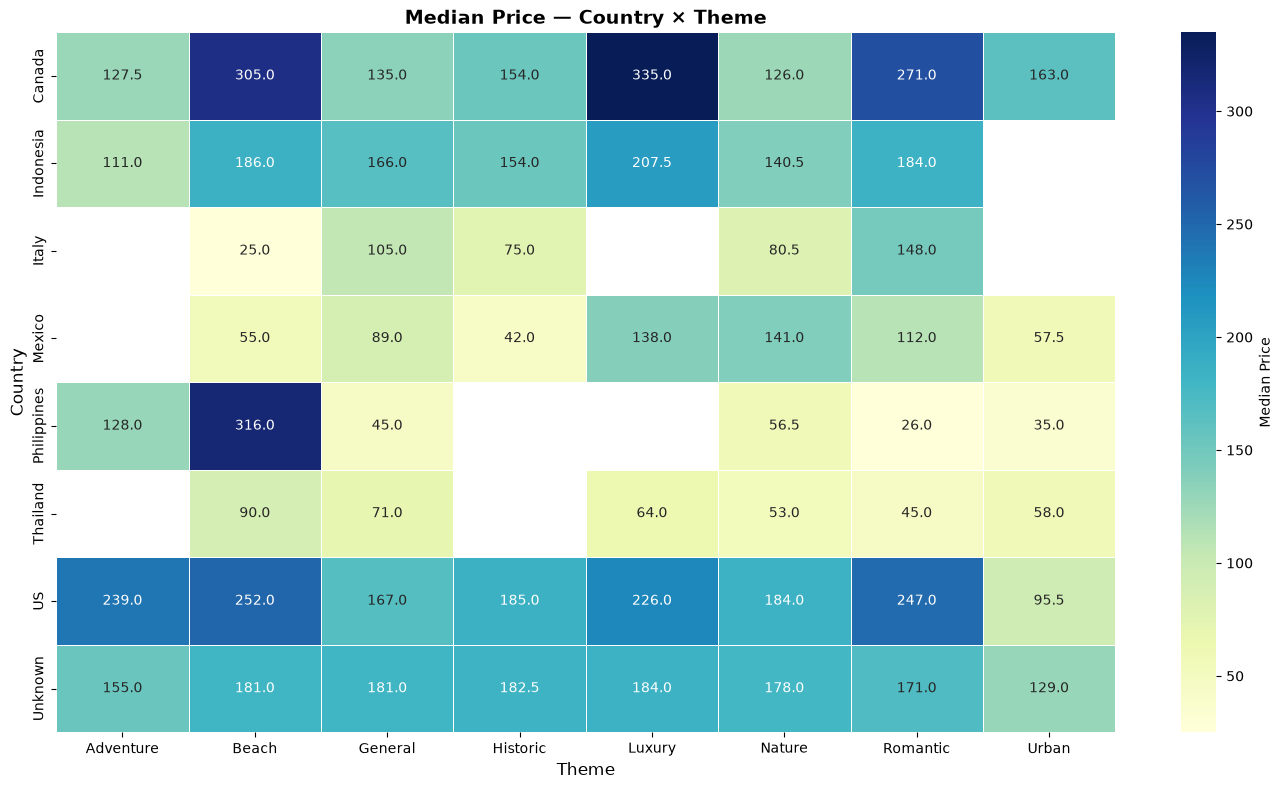

Theme,Adventure,Beach,General,Historic,Luxury,Nature,Romantic,Urban
Country,,,,,,,,
Canada,127.5,305.0,135.0,154.0,335.0,126.0,271.0,163.0
Indonesia,111.0,186.0,166.0,154.0,207.5,140.5,184.0,NaN
Italy,NaN,25.0,105.0,75.0,NaN,80.5,148.0,NaN
Mexico,NaN,55.0,89.0,42.0,138.0,141.0,112.0,57.5
Philippines,128.0,316.0,45.0,NaN,NaN,56.5,26.0,35.0
Thailand,NaN,90.0,71.0,NaN,64.0,53.0,45.0,58.0
US,239.0,252.0,167.0,185.0,226.0,184.0,247.0,95.5
Unknown,155.0,181.0,181.0,182.5,184.0,178.0,171.0,129.0


In [2]:
# ── 1.1  Country × Theme → Median Price ─────────────────────────────────────
# Q: Does a "Luxury" listing in Indonesia cost the same as one in the US?
#    Where are the best-value destinations for each travel theme?

multivariate_pivot_heatmap(
    df, "Country", "Theme", "Price",
    aggfunc="median", top_n_row=8, top_n_col=8,
)

Pivot Heatmap — Median Rating by Country × Theme
Theme        Adventure  Beach  General  Historic  Luxury  Nature  Romantic  Urban
Country                                                                          
Canada            4.97   4.87     4.97      4.84    5.00    4.89      4.97   4.90
Indonesia         4.89   4.93     4.84      4.89    4.91    4.88      4.97    NaN
Italy              NaN   4.98     4.88      4.98     NaN    4.89      4.88    NaN
Mexico             NaN   4.74     4.81      4.83    4.87    4.86      4.85   4.80
Philippines       4.62   4.91     4.89       NaN     NaN    4.85      4.78   4.92
Thailand           NaN   4.89     4.88       NaN    4.80    4.73      4.89   4.74
US                4.96   4.80     4.87      4.94    4.99    4.93      4.77   4.69
Unknown           4.94   4.90     4.92      4.93    4.87    4.96      4.94   4.96

  Grand median : 4.89
  Overall range  : 4.62 → 5.00


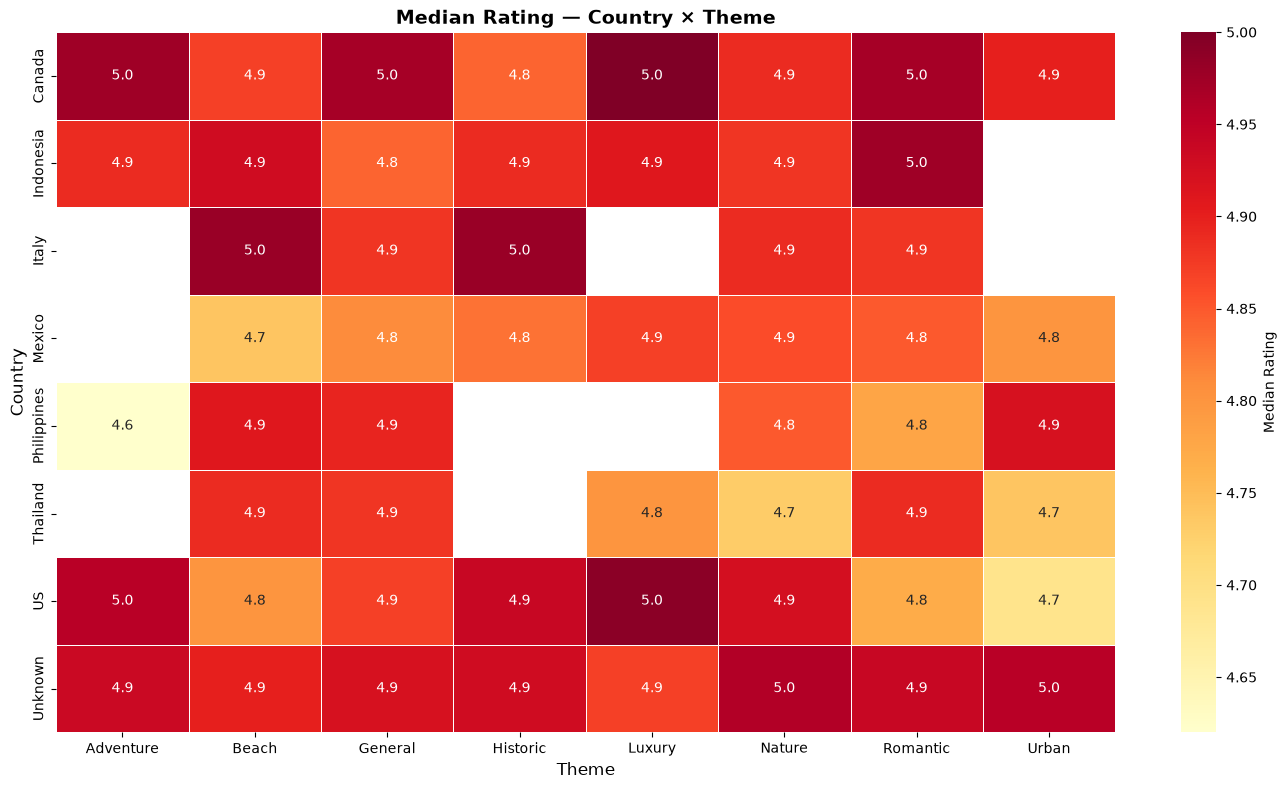

Theme,Adventure,Beach,General,Historic,Luxury,Nature,Romantic,Urban
Country,,,,,,,,
Canada,4.975,4.87,4.970,4.84,5.00,4.890,4.970,4.900
Indonesia,4.890,4.93,4.840,4.89,4.91,4.880,4.975,NaN
Italy,NaN,4.98,4.880,4.98,NaN,4.890,4.880,NaN
Mexico,NaN,4.74,4.810,4.83,4.87,4.860,4.850,4.800
Philippines,4.620,4.91,4.895,NaN,NaN,4.850,4.780,4.920
Thailand,NaN,4.89,4.880,NaN,4.80,4.730,4.890,4.740
US,4.955,4.80,4.870,4.94,4.99,4.925,4.770,4.690
Unknown,4.935,4.90,4.920,4.93,4.87,4.960,4.940,4.955


In [3]:
# ── 1.2  Country × Theme → Median Rating ───────────────────────────────────
# Q: Which country × theme combinations produce the highest-rated stays?
#    Are Nature stays in Canada rated higher than Nature stays in Thailand?

multivariate_pivot_heatmap(
    df, "Country", "Theme", "Rating",
    aggfunc="median", top_n_row=8, top_n_col=8,
    cmap="YlOrRd",
)

Pivot Heatmap — Median Price by Property_Type × Theme
Theme          Adventure  Beach  General  Historic  Luxury  Nature  Romantic  Urban
Property_Type                                                                      
Apartment          306.0  117.0     89.0     222.0    64.0   134.0      73.5   62.0
Cabin              287.0  132.0    191.5      44.0   228.0   148.5     238.0    NaN
Condo              112.0  190.0    108.0       NaN   184.0     NaN      39.5   34.5
Cottage             98.0  253.0    169.5     141.0     NaN   166.0     117.0    NaN
Guesthouse           NaN  101.5     99.0     115.0     NaN   188.0     104.0  111.0
Home               232.0  171.0    184.0       NaN   306.0   131.0     113.0  183.5
Room               111.5   81.0    100.0      55.0    92.0    57.5     142.0  144.0
Tiny home          117.0  219.0    112.0       NaN     NaN   128.5     107.0    NaN
Treehouse            NaN    NaN    135.0       NaN   232.0   207.0       NaN    NaN
Villa              111

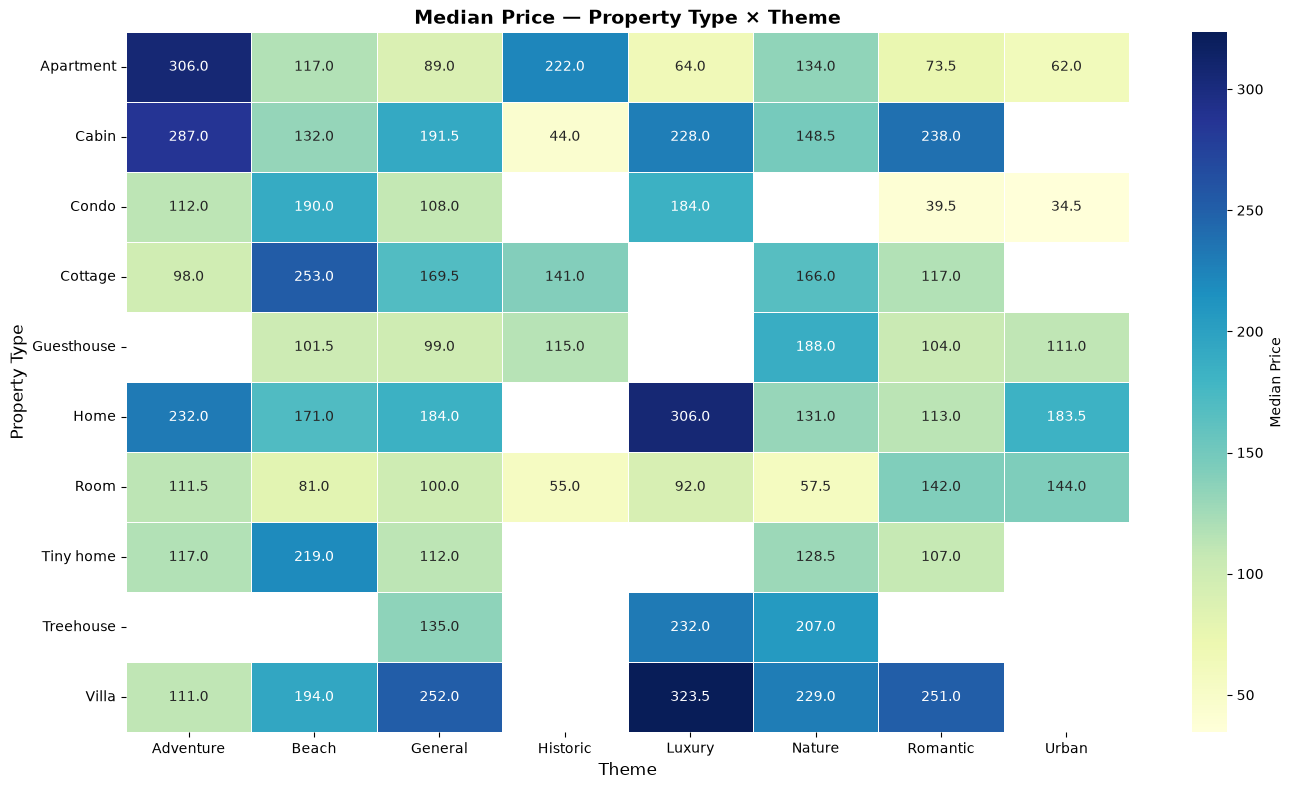

Theme,Adventure,Beach,General,Historic,Luxury,Nature,Romantic,Urban
Property_Type,,,,,,,,
Apartment,306.0,117.0,89.0,222.0,64.0,134.0,73.5,62.0
Cabin,287.0,132.0,191.5,44.0,228.0,148.5,238.0,NaN
Condo,112.0,190.0,108.0,NaN,184.0,NaN,39.5,34.5
Cottage,98.0,253.0,169.5,141.0,NaN,166.0,117.0,NaN
Guesthouse,NaN,101.5,99.0,115.0,NaN,188.0,104.0,111.0
Home,232.0,171.0,184.0,NaN,306.0,131.0,113.0,183.5
Room,111.5,81.0,100.0,55.0,92.0,57.5,142.0,144.0
Tiny home,117.0,219.0,112.0,NaN,NaN,128.5,107.0,NaN
Treehouse,NaN,NaN,135.0,NaN,232.0,207.0,NaN,NaN


In [4]:
# ── 1.3  Property Type × Theme → Median Price ──────────────────────────────
# Q: Is a Villa expensive because it's a Villa, or because it's usually
#    tagged as "Luxury"?  What does a "Nature" Villa cost vs. a "Beach" Villa?

multivariate_pivot_heatmap(
    df, "Property_Type", "Theme", "Price",
    aggfunc="median", top_n_row=10, top_n_col=8,
)

Pivot Heatmap — Median Rating by Property_Type × Theme
Theme          Adventure  Beach  General  Historic  Luxury  Nature  Romantic  Urban
Property_Type                                                                      
Apartment            NaN   4.76     4.78      4.94    4.85    4.84      4.82   4.84
Cabin               4.95   4.98     4.94      4.98    5.00    4.92      4.97    NaN
Condo               4.72   4.86     4.81       NaN    4.81     NaN      4.84   4.76
Cottage             4.95   4.91     4.93      5.00     NaN    4.93      4.92    NaN
Guesthouse           NaN   4.85     4.93      4.96     NaN    4.93      4.98   4.95
Home                4.82   4.89     4.90       NaN    5.00    4.86      4.95   4.94
Room                4.70   4.89     4.93      4.89    4.87    4.92      4.92   4.96
Tiny home           4.92   4.86     4.96       NaN     NaN    4.94      4.96    NaN
Treehouse            NaN    NaN     4.88       NaN    4.99    4.91       NaN    NaN
Villa               4

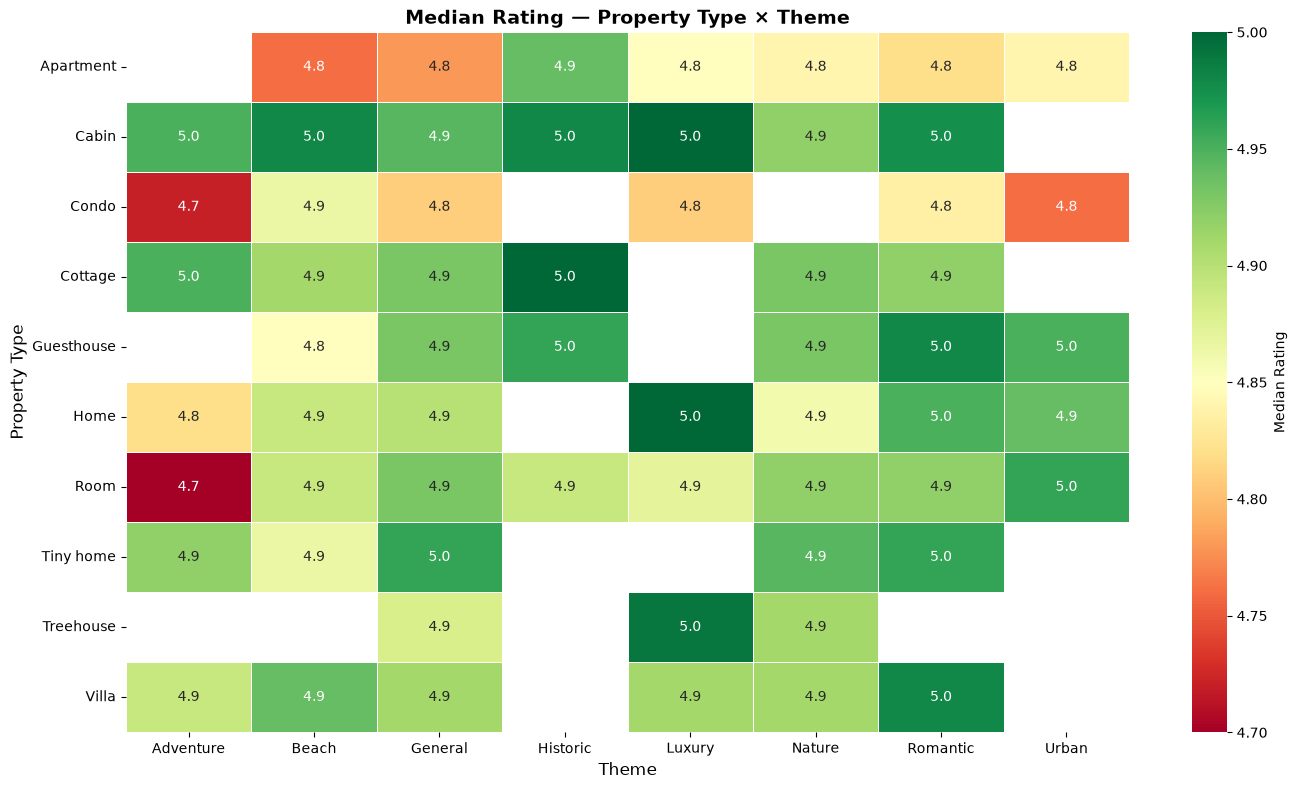

Theme,Adventure,Beach,General,Historic,Luxury,Nature,Romantic,Urban
Property_Type,,,,,,,,
Apartment,NaN,4.760,4.780,4.94,4.85,4.840,4.820,4.84
Cabin,4.95,4.980,4.945,4.98,5.00,4.920,4.975,NaN
Condo,4.72,4.865,4.810,NaN,4.81,NaN,4.835,4.76
Cottage,4.95,4.910,4.930,5.00,NaN,4.930,4.920,NaN
Guesthouse,NaN,4.850,4.930,4.96,NaN,4.930,4.980,4.95
Home,4.82,4.890,4.900,NaN,5.00,4.860,4.950,4.94
Room,4.70,4.890,4.930,4.89,4.87,4.920,4.920,4.96
Tiny home,4.92,4.865,4.960,NaN,NaN,4.945,4.960,NaN
Treehouse,NaN,NaN,4.880,NaN,4.99,4.910,NaN,NaN


In [5]:
# ── 1.4  Property Type × Theme → Median Rating ─────────────────────────────
# Q: Which property type × theme pairs produce the happiest guests?

multivariate_pivot_heatmap(
    df, "Property_Type", "Theme", "Rating",
    aggfunc="median", top_n_row=10, top_n_col=8,
    cmap="RdYlGn",
)

Pivot Heatmap — Median Price by Property_Type × Country
Country        Canada  Indonesia  Italy  Mexico  Philippines  Thailand     US  Unknown
Property_Type                                                                         
Apartment         NaN       79.5    NaN    78.0         72.5      59.5  185.0    153.0
Cabin           162.0      237.0  111.0   109.0         51.0     132.0  227.5    193.0
Condo             NaN        NaN  135.0   171.0         30.0      52.5  276.0    182.5
Home            402.0      229.0  102.0   113.0        136.0     171.0  239.0    222.0
Room              NaN       65.0   69.0    43.0         62.0      63.5  147.0    123.5
Tiny home       112.0      140.5    NaN   261.0         83.5       NaN  154.0    162.5
Treehouse       135.0      127.0    NaN   157.0        255.0       NaN  263.0    305.0
Villa             NaN      219.0  183.0     NaN        473.0     162.0  283.0    494.0

  Grand median : 163.50
  Overall range  : 30.00 → 494.00


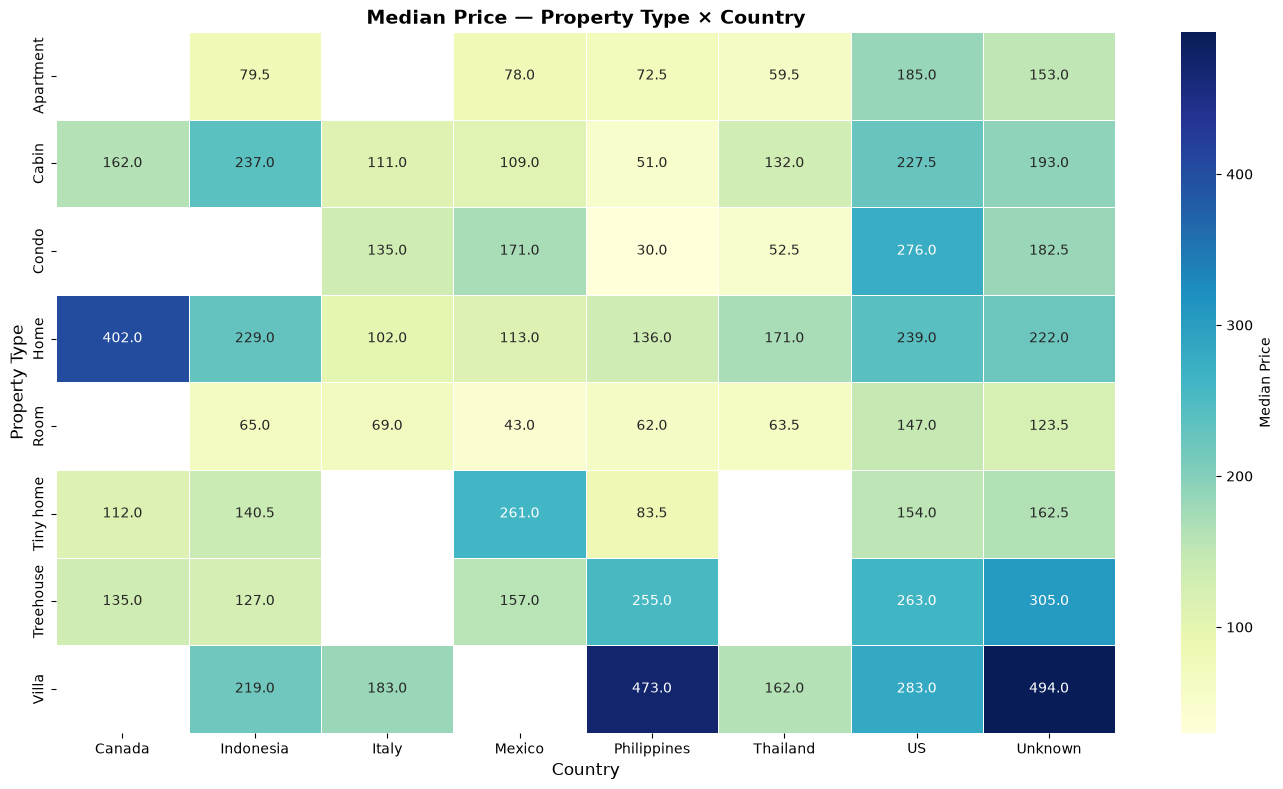

Country,Canada,Indonesia,Italy,Mexico,Philippines,Thailand,US,Unknown
Property_Type,,,,,,,,
Apartment,NaN,79.5,NaN,78.0,72.5,59.5,185.0,153.0
Cabin,162.0,237.0,111.0,109.0,51.0,132.0,227.5,193.0
Condo,NaN,NaN,135.0,171.0,30.0,52.5,276.0,182.5
Home,402.0,229.0,102.0,113.0,136.0,171.0,239.0,222.0
Room,NaN,65.0,69.0,43.0,62.0,63.5,147.0,123.5
Tiny home,112.0,140.5,NaN,261.0,83.5,NaN,154.0,162.5
Treehouse,135.0,127.0,NaN,157.0,255.0,NaN,263.0,305.0
Villa,NaN,219.0,183.0,NaN,473.0,162.0,283.0,494.0


In [6]:
# ── 1.5  Property Type × Country → Median Price ────────────────────────────
# Q: Are Cabins in the US priced similarly to Cabins in Canada?
#    Do Villas in Indonesia compete with Villas in Italy on price?

multivariate_pivot_heatmap(
    df, "Property_Type", "Country", "Price",
    aggfunc="median", top_n_row=8, top_n_col=8,
)


Pivot Heatmap — Median Price by Theme × Bed_Type
Bed_Type    Bunk  Double   King  Queen  Single   Sofa  Standard
Theme                                                          
Adventure    NaN   287.0  107.0  172.0     NaN    NaN     133.5
Beach        NaN   128.5  143.5  147.0     NaN  279.0     171.0
Family       NaN    51.0   73.0    NaN    73.0   71.0     104.0
General     22.0    96.0  102.5  165.0   116.0   78.0     132.0
Historic     NaN     NaN  141.0  203.0    44.0    NaN     129.0
Luxury       NaN   142.0   87.0  164.0   159.0  183.0     147.0
Nature       NaN   128.5  169.0  143.0    98.0   93.0     137.5
Romantic   251.0   108.0  209.0  107.0    75.0    NaN     112.0
Urban        NaN    93.0   60.0   50.5     NaN   87.5     108.0

  Grand median : 135.00
  Overall range  : 22.00 → 287.00


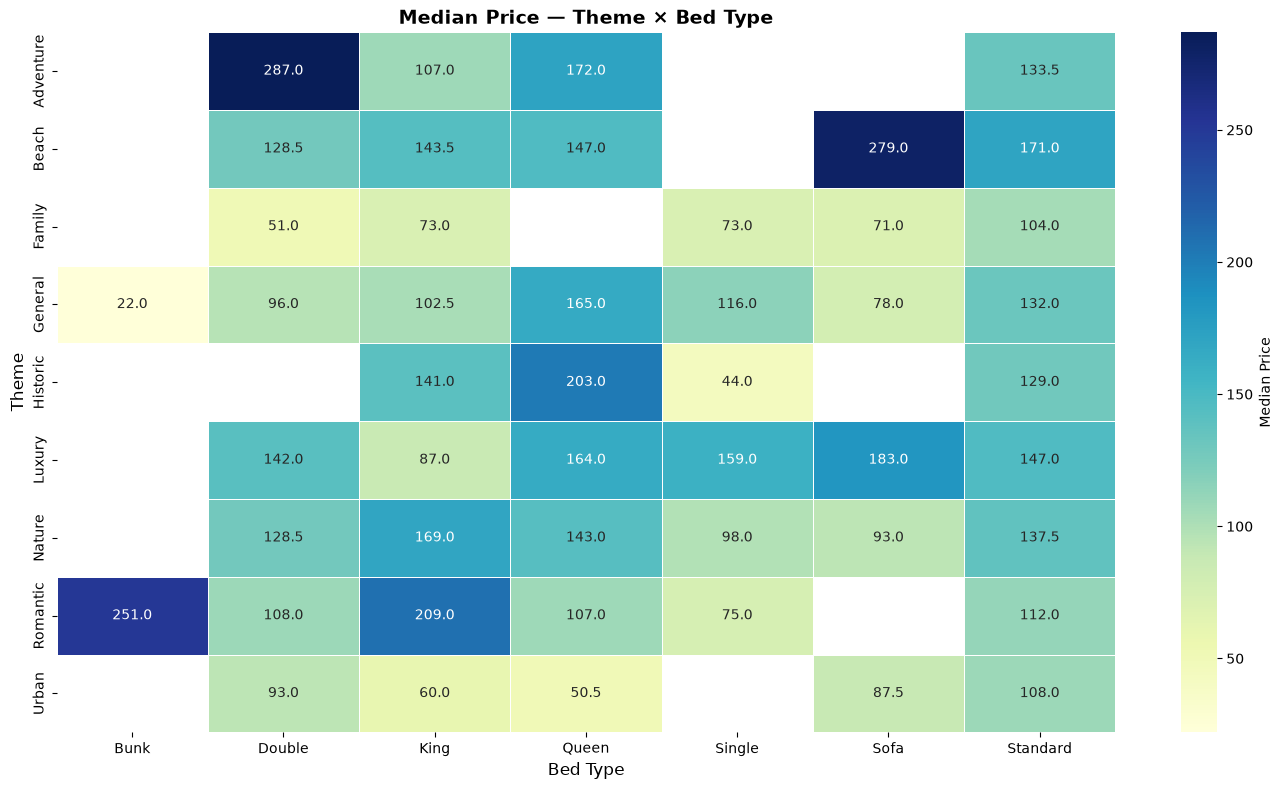

Bed_Type,Bunk,Double,King,Queen,Single,Sofa,Standard
Theme,,,,,,,
Adventure,NaN,287.0,107.0,172.0,NaN,NaN,133.5
Beach,NaN,128.5,143.5,147.0,NaN,279.0,171.0
Family,NaN,51.0,73.0,NaN,73.0,71.0,104.0
General,22.0,96.0,102.5,165.0,116.0,78.0,132.0
Historic,NaN,NaN,141.0,203.0,44.0,NaN,129.0
Luxury,NaN,142.0,87.0,164.0,159.0,183.0,147.0
Nature,NaN,128.5,169.0,143.0,98.0,93.0,137.5
Romantic,251.0,108.0,209.0,107.0,75.0,NaN,112.0
Urban,NaN,93.0,60.0,50.5,NaN,87.5,108.0


In [7]:
# ── 1.6  Theme × Bed Type → Median Price ───────────────────────────────────
# Q: Do King beds command a premium only in "Luxury" themes, or across
#    all themes equally?

multivariate_pivot_heatmap(
    df, "Theme", "Bed_Type", "Price",
    aggfunc="median", top_n_row=9, top_n_col=7,
)

Pivot Heatmap — Mean Review_Count by Country × Theme
Theme        Adventure   Beach  General  Historic  Luxury  Nature  Romantic   Urban
Country                                                                            
Canada          124.83  137.29   137.20     95.00   16.00  245.24    173.40  289.00
Indonesia       364.00  141.48   147.86    111.00  116.96  158.88    170.50     NaN
Italy              NaN  245.00   125.67     46.00     NaN  194.00    128.33     NaN
Mexico             NaN  246.27   171.42    250.50  149.20  317.67    175.00  189.00
Philippines     112.33   48.20   226.38       NaN     NaN  105.00    337.14  196.00
Thailand           NaN  100.56   136.67       NaN  153.18   11.00    144.43  252.00
US              217.71  286.94   194.12    431.00  193.25  259.58    120.60  274.50
Unknown         255.14  193.33   217.77    216.83  233.12  287.38    313.14  493.25

  Grand mean : 202.49
  Overall range  : 11.00 → 493.25


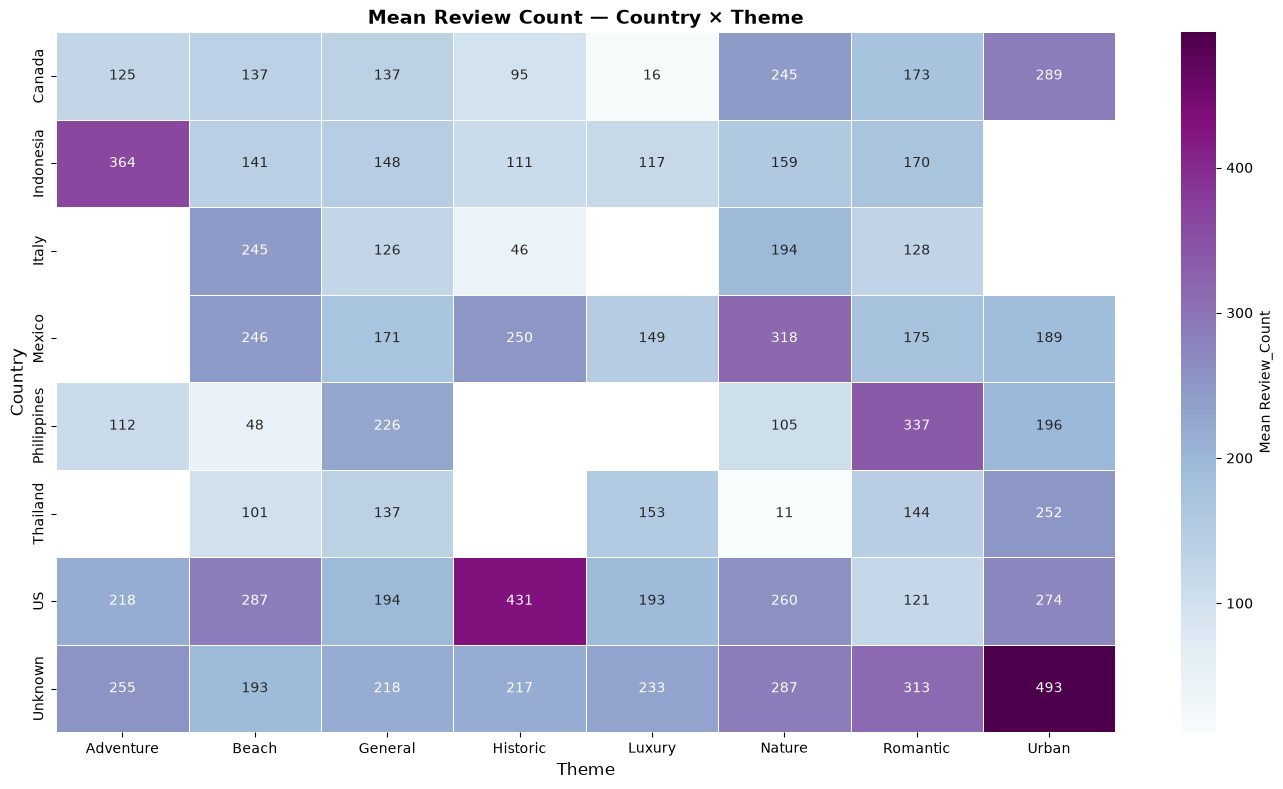

Theme,Adventure,Beach,General,Historic,Luxury,Nature,Romantic,Urban
Country,,,,,,,,
Canada,124.833333,137.285714,137.200000,95.000000,16.000000,245.235294,173.400000,289.00
Indonesia,364.000000,141.478261,147.857143,111.000000,116.964286,158.875000,170.500000,NaN
Italy,NaN,245.000000,125.666667,46.000000,NaN,194.000000,128.333333,NaN
Mexico,NaN,246.272727,171.416667,250.500000,149.200000,317.666667,175.000000,189.00
Philippines,112.333333,48.200000,226.375000,NaN,NaN,105.000000,337.142857,196.00
Thailand,NaN,100.555556,136.666667,NaN,153.181818,11.000000,144.428571,252.00
US,217.714286,286.942857,194.115385,431.000000,193.250000,259.580645,120.600000,274.50
Unknown,255.142857,193.333333,217.765432,216.833333,233.117647,287.381818,313.142857,493.25


In [8]:
# ── 1.7  Country × Theme → Mean Review Count ───────────────────────────────
# Q: Where are the most-reviewed (most popular) stays for each theme?

multivariate_pivot_heatmap(
    df, "Country", "Theme", "Review_Count",
    aggfunc="mean", top_n_row=8, top_n_col=8,
    cmap="BuPu", fmt=".0f",
)

Grouped Box Plot — Price by Property_Type, split by Has_Pool
                        count  median    mean
Property_Type Has_Pool                       
Apartment     False        96   107.0  129.60
              True         23    64.0   91.74
Cabin         False       114   171.0  191.51
              True          2   296.0  296.00
Condo         False        86   141.5  168.56
              True          9   145.0  165.44
Home          False       101   173.0  235.48
              True         22   213.0  250.23
Room          False        78    92.0  104.62
              True          5   101.0   85.40
Tiny home     False        41   123.0  136.66
              True          1   162.0  162.00
Treehouse     False        31   207.0  228.87
              True          6   169.0  269.67
Villa         False        37   251.0  300.89
              True         25   189.0  266.64


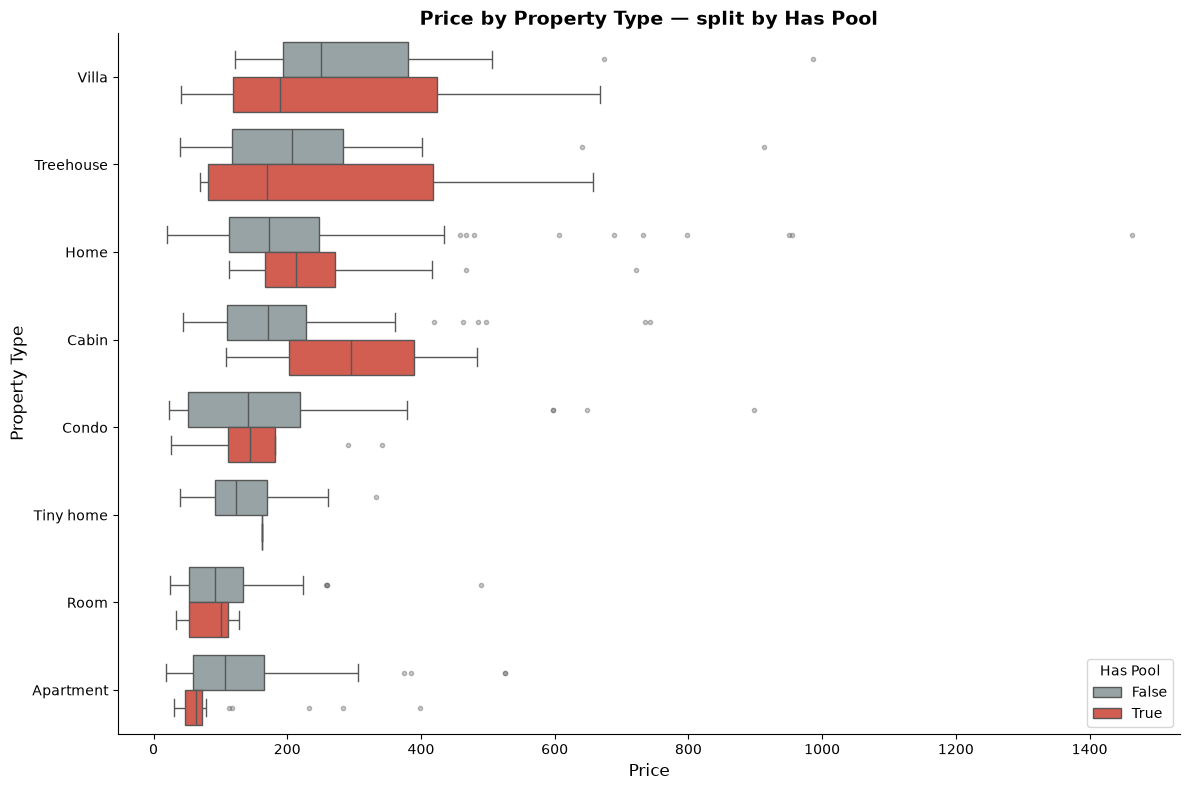

In [9]:
# ── 2.1  Property Type × Has_Pool → Price ──────────────────────────────────
# Q: Does a pool add the same price premium to a Villa as to an Apartment?
#    (Bivariate showed pools don't raise the overall median — but maybe
#     they DO raise it within specific property types.)

multivariate_grouped_boxplot(df, "Property_Type", "Has_Pool", "Price", top_n=8)


Grouped Box Plot — Price by Property_Type, split by Is_Near_Beach
                             count  median    mean
Property_Type Is_Near_Beach                       
Apartment     False             83    80.0  111.29
              True              36   139.0  147.64
Cabin         False            107   173.0  194.60
              True               9   132.0  178.00
Condo         False             55    75.0  112.69
              True              40   216.5  244.68
Home          False             92   178.0  204.78
              True              31   198.0  337.03
Room          False             72    93.0  105.99
              True              11    81.0   86.91
Tiny home     False             37   118.0  123.76
              True               5   252.0  237.20
Treehouse     False             34   223.0  245.91
              True               3   121.0  117.33
Villa         False             43   209.0  263.26
              True              19   240.0  341.00


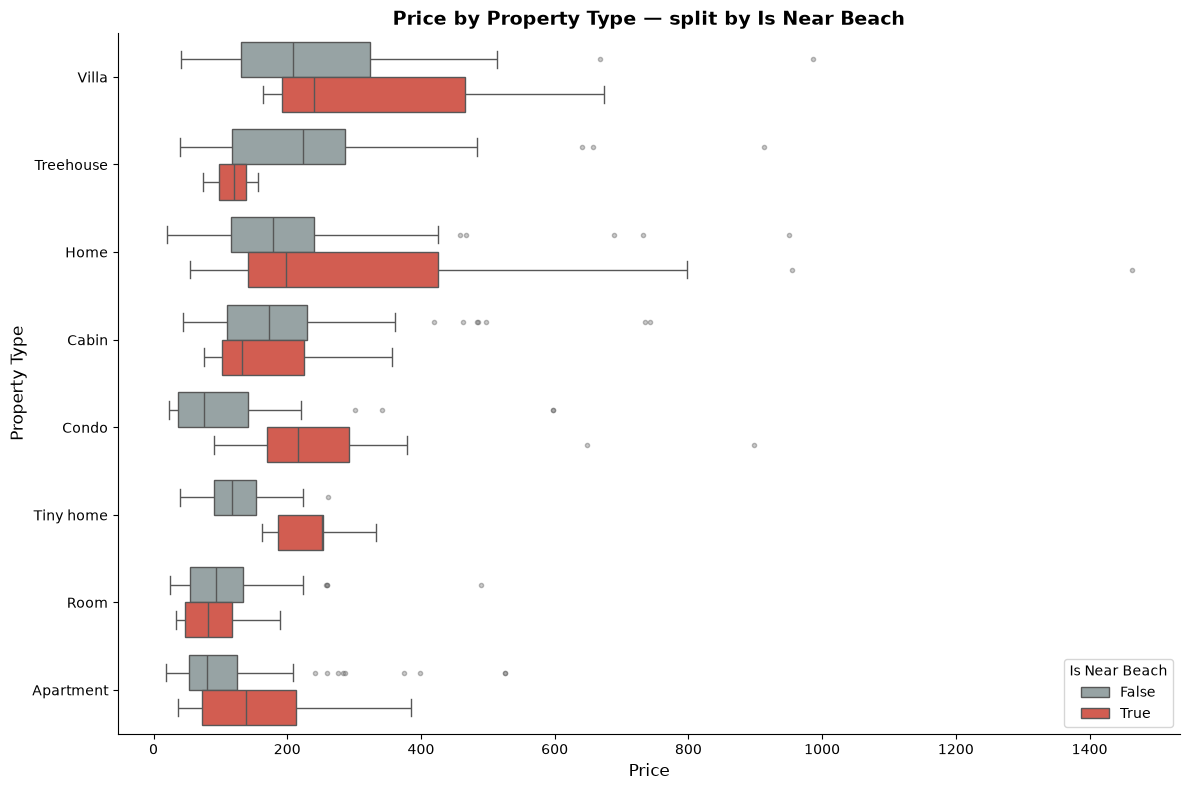

In [10]:
# ── 2.2  Property Type × Is_Near_Beach → Price ─────────────────────────────
# Q: Does beach proximity add the same premium to a Cabin as to a Condo?

multivariate_grouped_boxplot(df, "Property_Type", "Is_Near_Beach", "Price", top_n=8)


Grouped Box Plot — Price by Theme, split by Has_Pool
                    count  median    mean
Theme     Has_Pool                       
Adventure False        28   133.5  173.11
          True          2   111.5  111.50
Beach     False       172   164.0  212.32
          True         36   146.0  208.75
General   False       284   115.0  150.77
          True         40   135.0  184.75
Historic  False        20   141.0  138.25
Luxury    False        67   159.0  200.42
          True         22   112.0  146.64
Nature    False       173   139.0  171.44
          True          9   131.0  278.11
Romantic  False        47   117.0  155.94
          True          7   111.0  110.86
Urban     False        33    75.0   89.42
          True          1   113.0  113.00


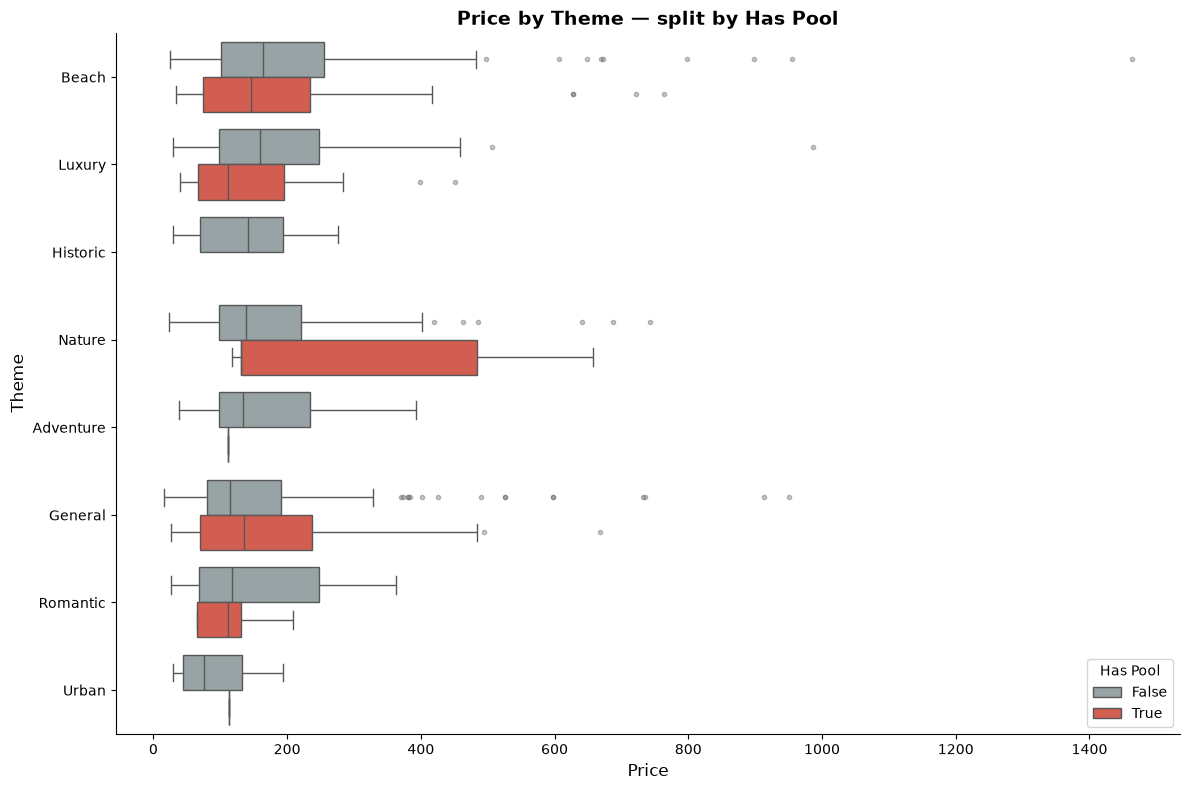

In [11]:
# ── 2.3  Theme × Has_Pool → Price ──────────────────────────────────────────
# Q: Does a pool add value equally to a "Nature" stay vs. a "Beach" stay?
#    (A pool might be expected at Beach, but a surprise differentiator
#     at Nature.)

multivariate_grouped_boxplot(df, "Theme", "Has_Pool", "Price", top_n=8)


Grouped Box Plot — Price by Theme, split by Has_Waterfront
                          count  median    mean
Theme     Has_Waterfront                       
Adventure False              30   128.5  169.00
Beach     False             138   150.5  210.99
          True               70   178.5  213.10
General   False             324   116.5  154.97
Historic  False              20   141.0  138.25
Luxury    False              88   144.5  186.00
          True                1   286.0  286.00
Nature    False             177   136.0  172.90
          True                5   232.0  311.60
Romantic  False              53   112.0  147.81
          True                1   271.0  271.00
Urban     False              34    77.5   90.12


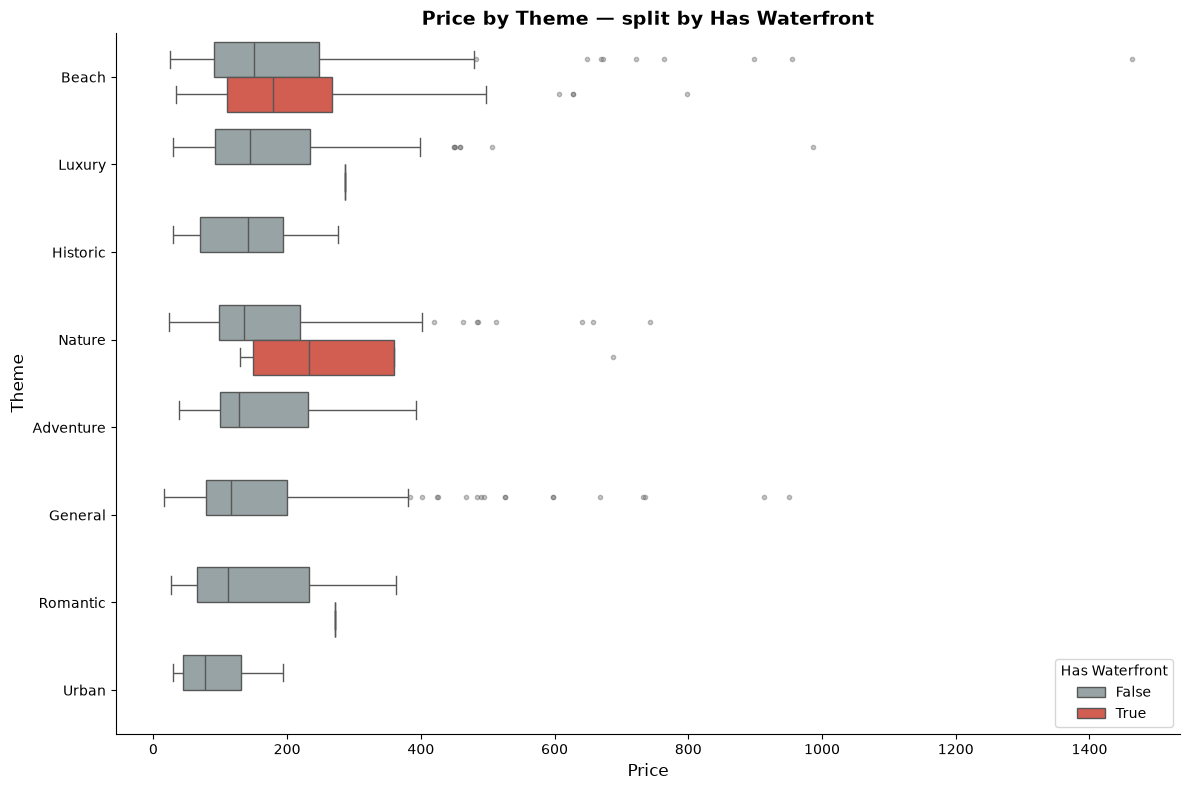

In [12]:
# ── 2.4  Theme × Has_Waterfront → Price ────────────────────────────────────
# Q: How much does waterfront access differentiate pricing within each theme?

multivariate_grouped_boxplot(df, "Theme", "Has_Waterfront", "Price", top_n=8)


Grouped Box Plot — Rating by Theme, split by Is_Near_Beach
                         count  median  mean
Theme     Is_Near_Beach                     
Adventure False             27    4.95  4.88
          True               1    4.62  4.62
Beach     False             44    4.86  4.83
          True             160    4.88  4.83
General   False            311    4.89  4.86
          True               2    4.92  4.92
Historic  False             18    4.94  4.92
          True               2    4.94  4.94
Luxury    False             76    4.88  4.87
          True              12    4.87  4.85
Nature    False            170    4.91  4.89
          True               8    4.92  4.89
Romantic  False             49    4.90  4.85
          True               5    4.88  4.88
Urban     False             34    4.89  4.84


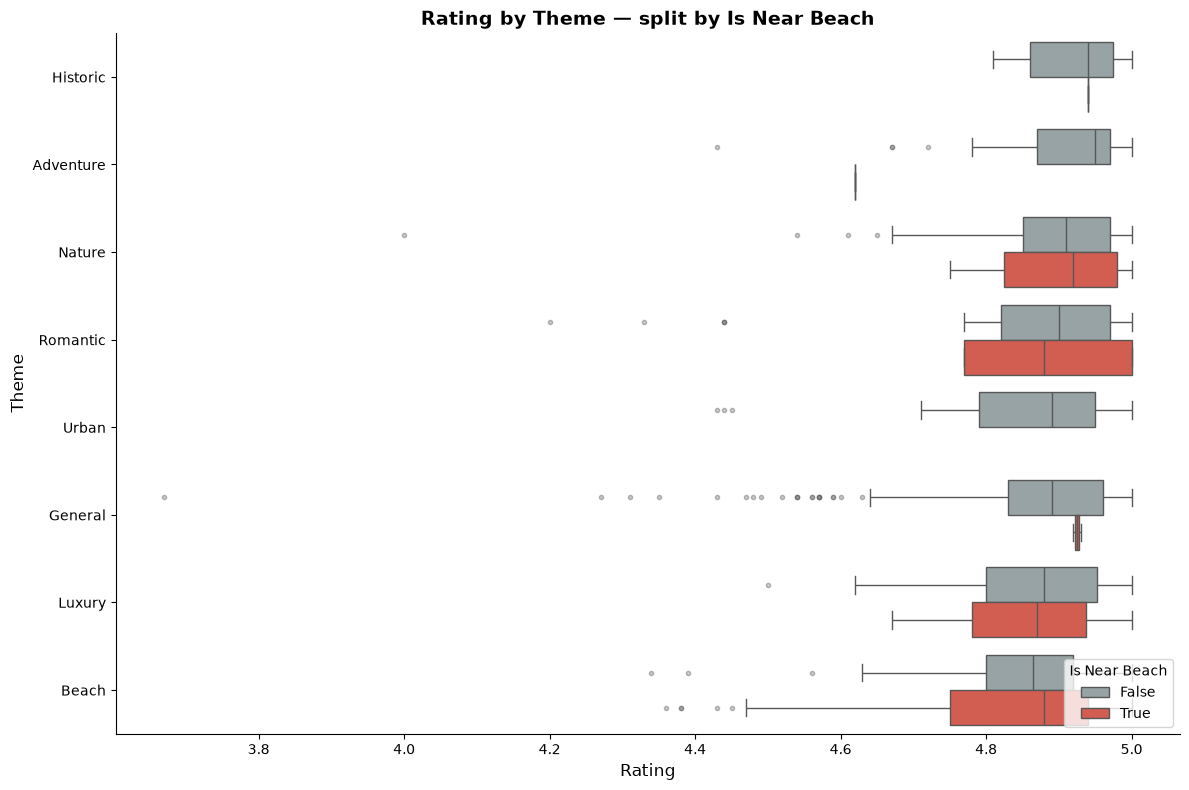

In [13]:
# ── 2.5  Theme × Is_Near_Beach → Rating ────────────────────────────────────
# Q: Within "Nature" or "Romantic" themes, does being near a beach
#    improve ratings, or does it create mismatched expectations?

multivariate_grouped_boxplot(df, "Theme", "Is_Near_Beach", "Rating", top_n=8)


Grouped Box Plot — Price by Country, split by Has_Pool
                      count  median    mean
Country     Has_Pool                       
Canada      False        43   154.0  206.65
            True          1   764.0  764.00
Indonesia   False        82   194.0  216.62
            True         28   123.5  172.46
Italy       False        33    92.0  107.24
            True          1   148.0  148.00
Mexico      False        36    67.0   91.64
            True          4    97.0  128.75
Philippines False        32    51.0  111.03
            True          5   424.0  401.20
Thailand    False        47    75.0  105.83
            True         22    64.5   91.32
US          False       107   220.0  246.67
            True          8   287.0  320.00
Unknown     False       224   173.0  202.81
            True         27   213.0  254.89


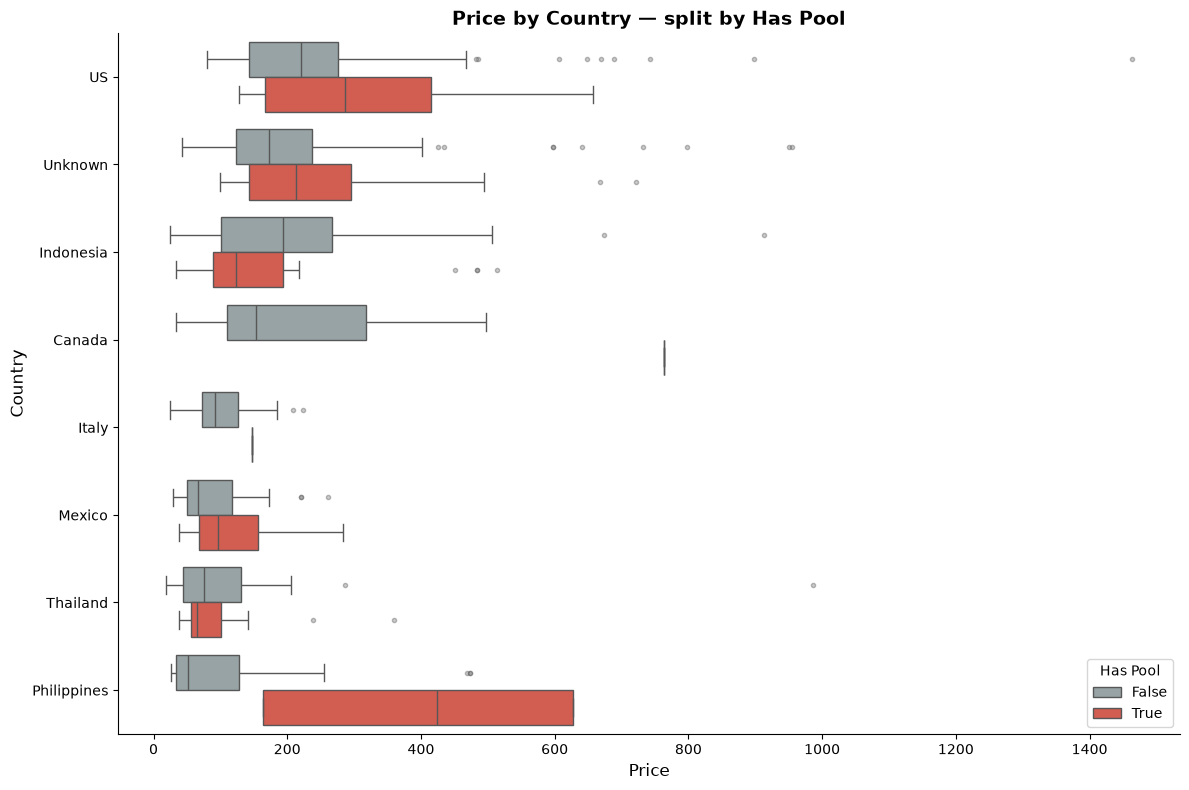

In [14]:
# ── 2.6  Country × Has_Pool → Price ────────────────────────────────────────
# Q: In which countries does a pool carry the biggest price premium?

multivariate_grouped_boxplot(df, "Country", "Has_Pool", "Price", top_n=8)



Grouped Box Plot — Price by Property_Type, split by Has_Hot_Tub
                           count  median    mean
Property_Type Has_Hot_Tub                       
Apartment     False          119    90.0  122.29
Cabin         False          104   148.5  186.96
              True            12   223.5  248.33
Condo         False           94   143.5  167.79
              True             1   213.0  213.00
Home          False          114   183.5  234.93
              True             9   192.0  278.44
Room          False           83    92.0  103.46
Tiny home     False           42   125.0  137.26
Treehouse     False           35   190.0  233.80
              True             2   265.0  265.00
Villa         False           60   209.0  280.80
              True             2   475.5  475.50


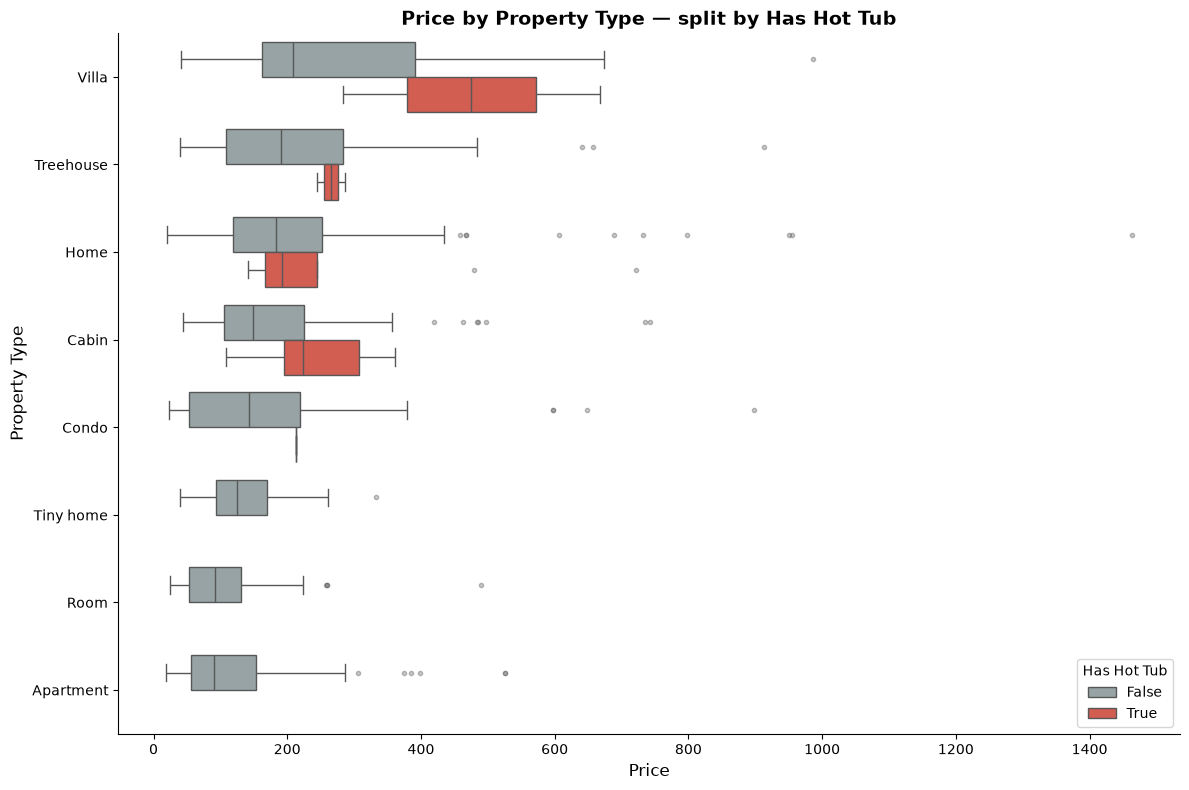

In [15]:
# ── 2.7  Property Type × Has_Hot_Tub → Price ───────────────────────────────
# Q: Hot tubs showed an +84.8% premium overall.  Is that driven by
#    specific property types (Cabins?) or consistent across the board?

multivariate_grouped_boxplot(df, "Property_Type", "Has_Hot_Tub", "Price", top_n=8)


Facet Scatter — Rating vs Price, faceted by Property_Type
  Home                  n =  118   Pearson r = +0.0574
  Apartment             n =  116   Pearson r = +0.2336
  Cabin                 n =  113   Pearson r = +0.2853
  Condo                 n =   95   Pearson r = +0.2004
  Room                  n =   82   Pearson r = +0.1792
  Villa                 n =   61   Pearson r = +0.1321


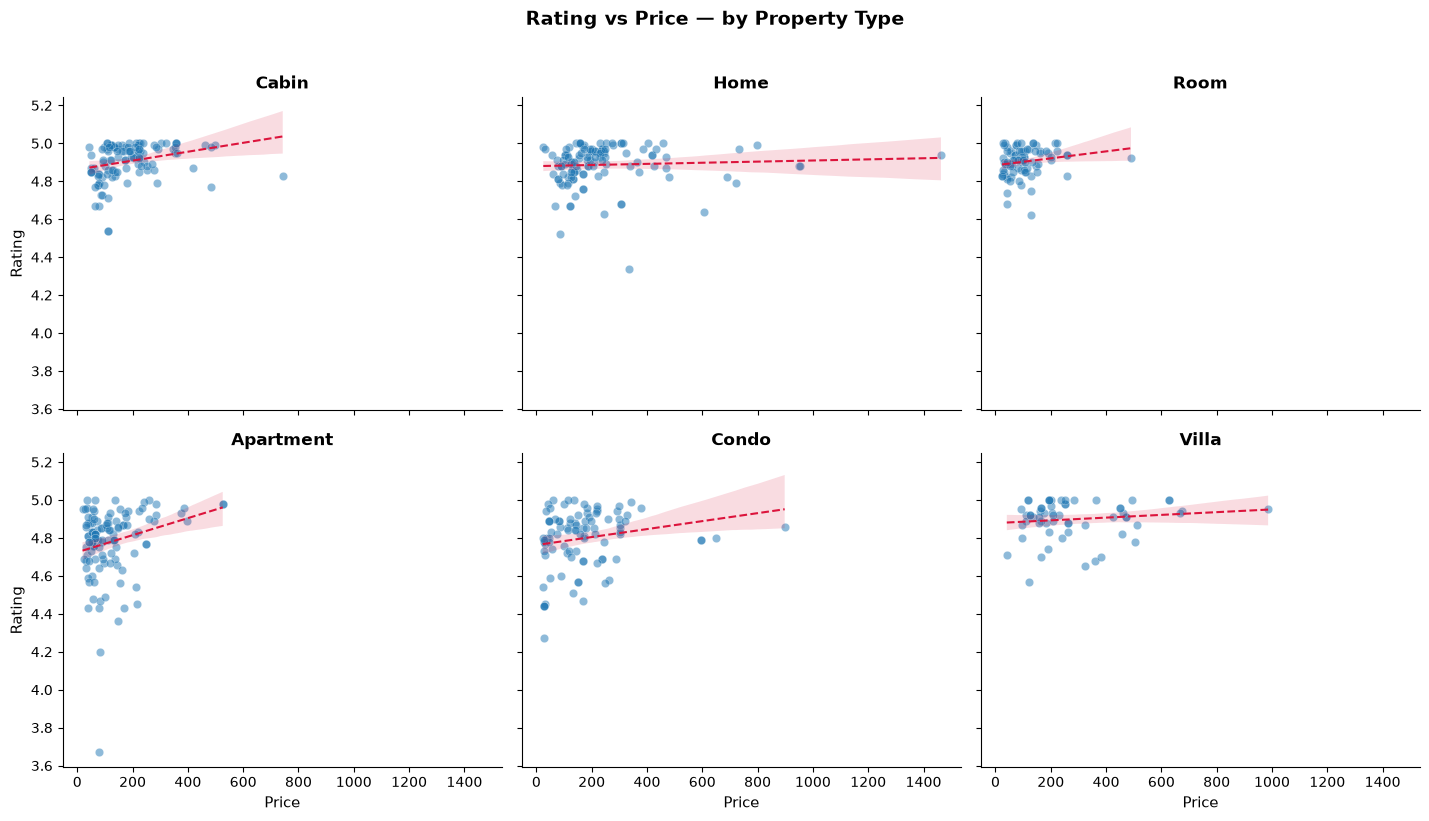

In [16]:
# ── 3.1  Price vs Rating — faceted by Property Type ─────────────────────────
# Q: Is the weak Price-Rating correlation (r = +0.18) consistent across
#    property types, or do some types show a stronger link?

multivariate_facet_scatter(
    df, "Price", "Rating", "Property_Type",
    top_n_facets=6, col_wrap=3,
)

Facet Scatter — Rating vs Price, faceted by Theme
  General               n =  313   Pearson r = +0.2157
  Beach                 n =  204   Pearson r = +0.1365
  Nature                n =  178   Pearson r = +0.2150
  Luxury                n =   88   Pearson r = +0.2933
  Romantic              n =   54   Pearson r = +0.4150
  Urban                 n =   34   Pearson r = +0.4415


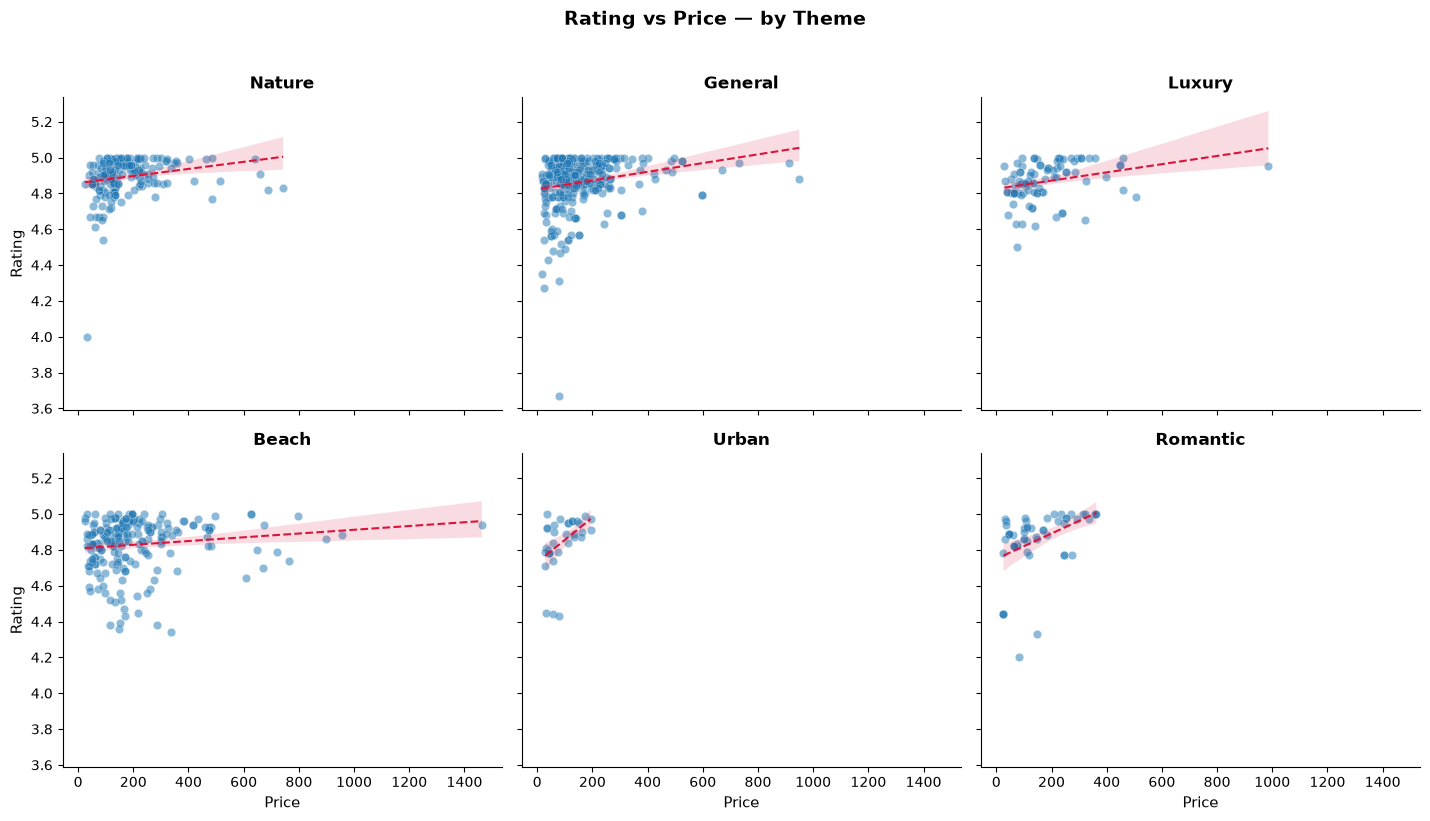

In [17]:
# ── 3.2  Price vs Rating — faceted by Theme ─────────────────────────────────
# Q: Does the price-quality relationship differ by theme?  Do "Luxury"
#    listings show a stronger correlation?

multivariate_facet_scatter(
    df, "Price", "Rating", "Theme",
    top_n_facets=6, col_wrap=3,
)


Facet Scatter — Rating vs Price, faceted by Country
  Unknown               n =  249   Pearson r = +0.1296
  US                    n =  109   Pearson r = +0.0000
  Indonesia             n =  109   Pearson r = +0.2165
  Thailand              n =   69   Pearson r = +0.1349
  Canada                n =   44   Pearson r = +0.2072
  Mexico                n =   39   Pearson r = +0.3824


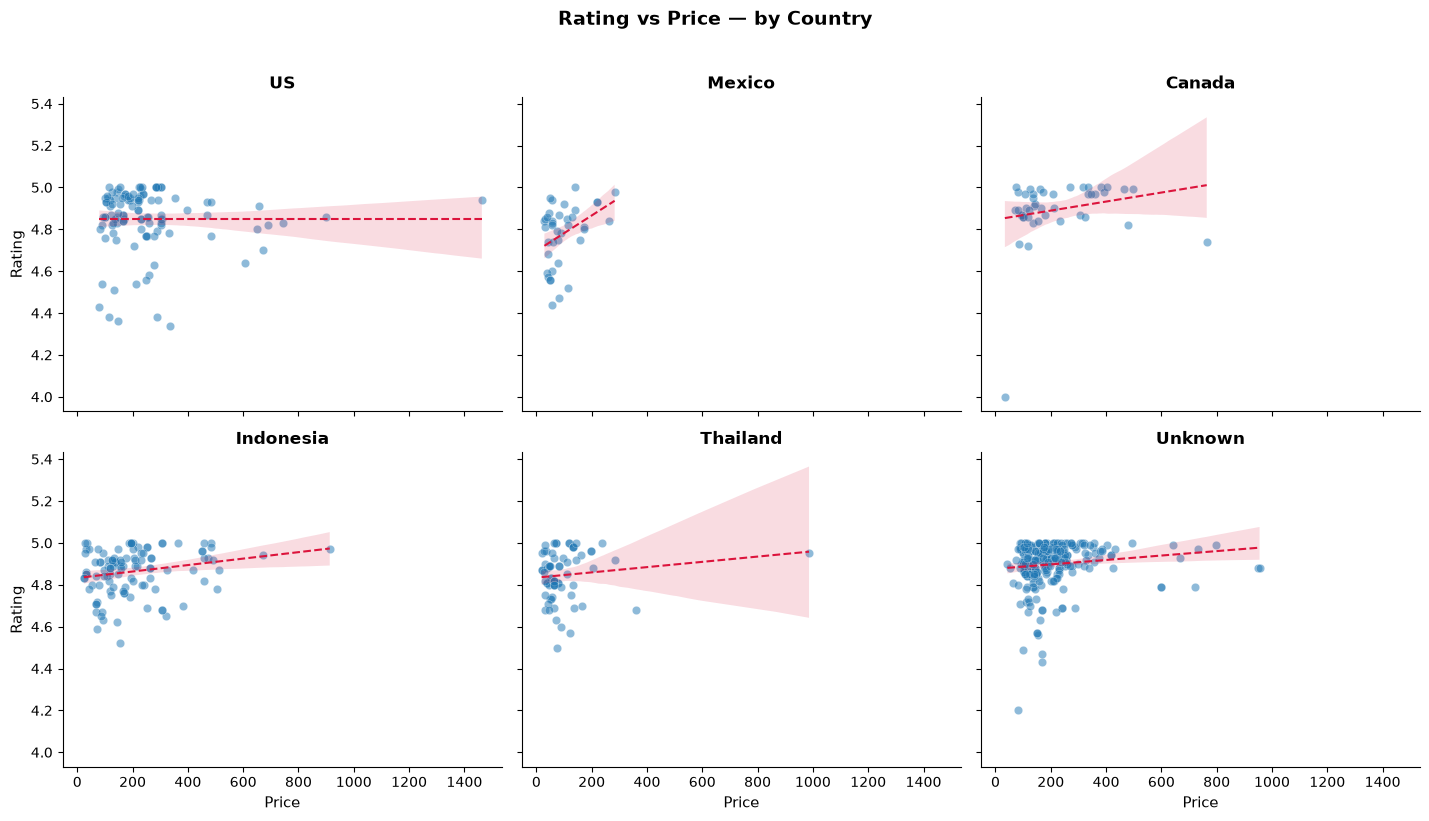

In [18]:
# ── 3.3  Price vs Rating — faceted by Country ───────────────────────────────
# Q: Does the price-quality disconnect hold in every country?

multivariate_facet_scatter(
    df, "Price", "Rating", "Country",
    top_n_facets=6, col_wrap=3,
)


Facet Scatter — Price vs Bed_Count, faceted by Theme
  General               n =  324   Pearson r = +0.2062
  Beach                 n =  208   Pearson r = +0.3551
  Nature                n =  182   Pearson r = +0.0453
  Luxury                n =   89   Pearson r = +0.5802
  Romantic              n =   54   Pearson r = -0.2287
  Urban                 n =   34   Pearson r = +0.0925


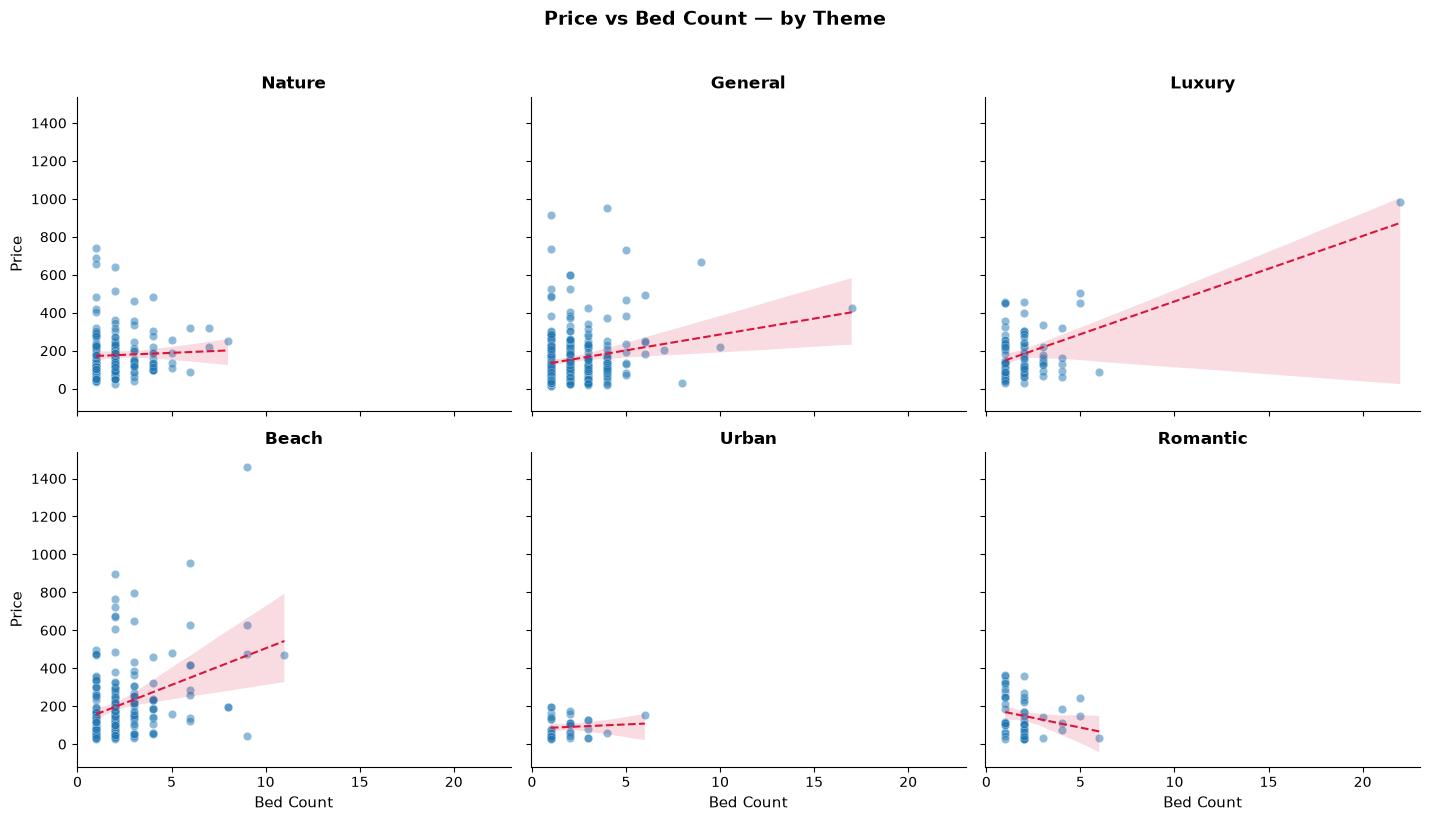

In [19]:
# ── 3.4  Price vs Bed Count — faceted by Theme ──────────────────────────────
# Q: Does adding more beds translate to proportionally more revenue
#    across all themes, or only in "Family" / "Beach" themes?

multivariate_facet_scatter(
    df, "Bed_Count", "Price", "Theme",
    top_n_facets=6, col_wrap=3,
)

Facet Scatter — Price vs Review_Count, faceted by Property_Type
  Home                  n =  122   Pearson r = -0.0615
  Apartment             n =  119   Pearson r = +0.0936
  Cabin                 n =  115   Pearson r = -0.1458
  Condo                 n =   95   Pearson r = +0.1864
  Room                  n =   82   Pearson r = +0.0342
  Villa                 n =   62   Pearson r = -0.2394


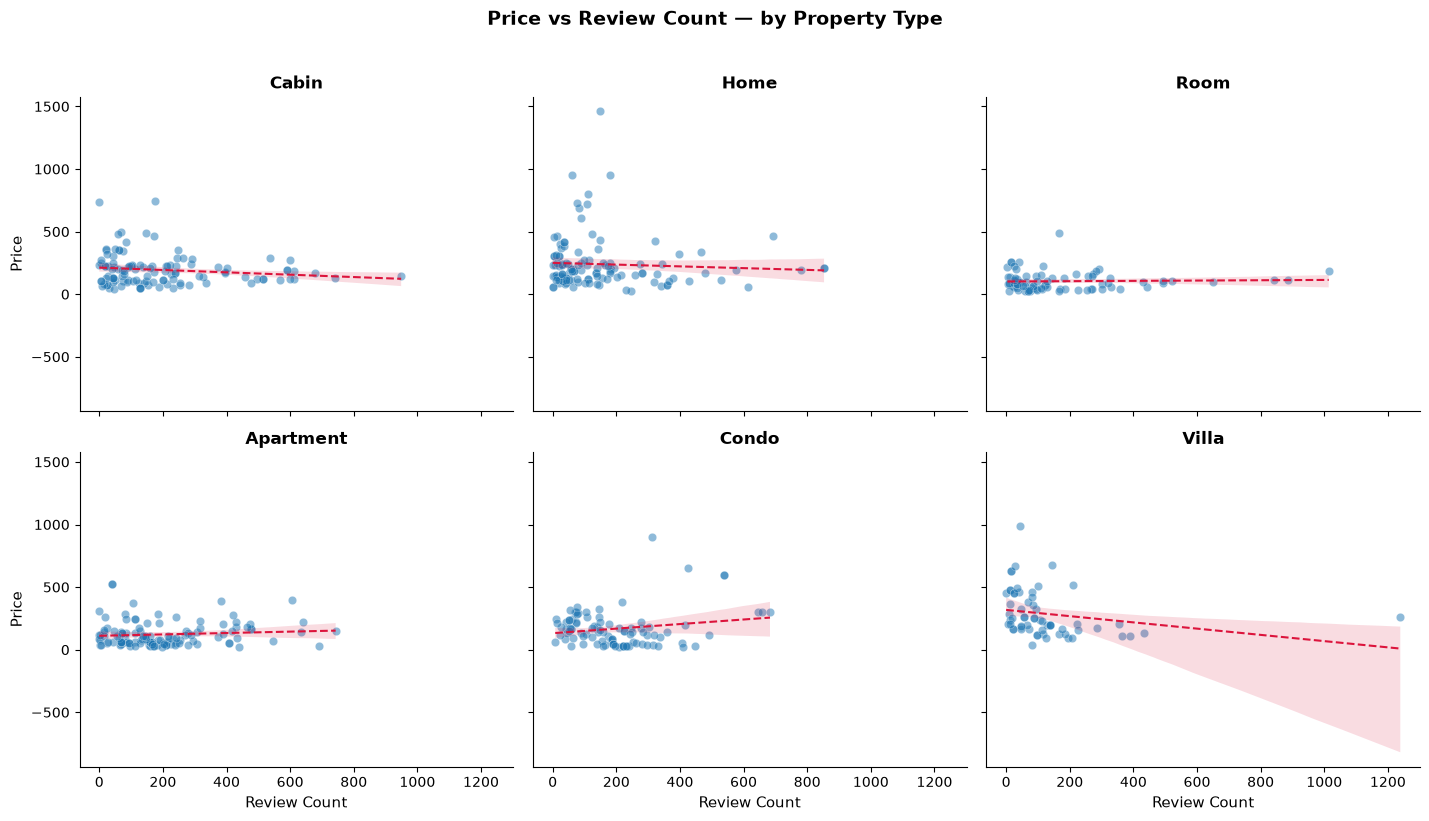

In [20]:
# ── 3.5  Price vs Review Count — faceted by Property Type ───────────────────
# Q: Are high-review Villas priced differently from high-review Apartments?

multivariate_facet_scatter(
    df, "Review_Count", "Price", "Property_Type",
    top_n_facets=6, col_wrap=3,
)


Pairplot — Price, Rating, Review_Count, Bed_Count coloured by Theme

  Theme = General  (n = 313)
       Price  Rating  Review_Count  Bed_Count
mean  155.71    4.86        168.50       2.21
50%   121.00    4.89        108.00       2.00
std   128.31    0.14        171.43       1.63

  Theme = Beach  (n = 204)
       Price  Rating  Review_Count  Bed_Count
mean  213.40    4.83        187.27       2.41
50%   162.50    4.87        139.00       2.00
std   188.85    0.15        166.42       1.74

  Theme = Nature  (n = 178)
       Price  Rating  Review_Count  Bed_Count
mean  174.72    4.89        231.52       2.09
50%   135.50    4.91        164.50       2.00
std   120.96    0.11        216.79       1.32

  Theme = Luxury  (n = 88)
       Price  Rating  Review_Count  Bed_Count
mean  184.12    4.87        155.84       2.07
50%   144.50    4.88        106.00       2.00
std   140.28    0.11        155.81       2.39



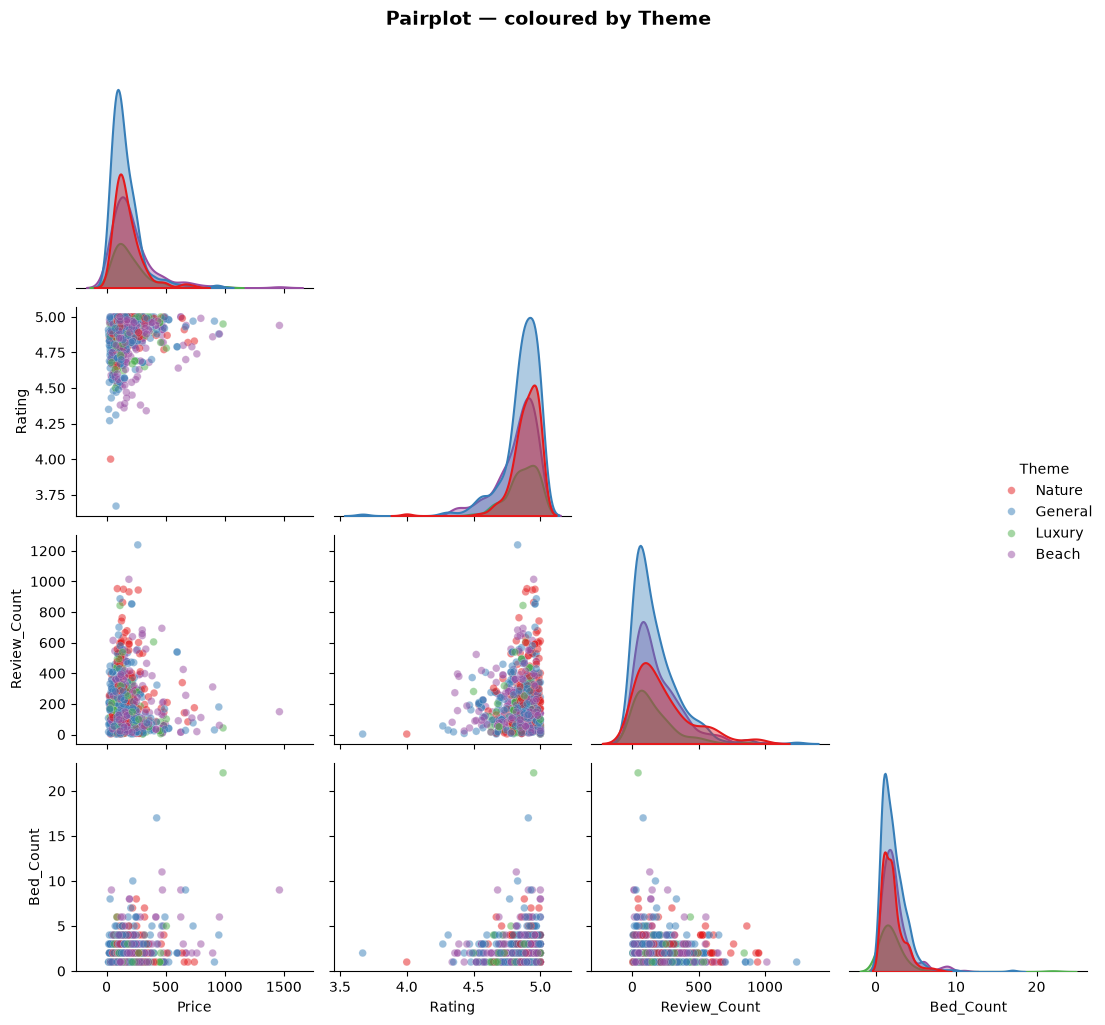

In [21]:
# ── 4.1  Core Pricing Metrics — coloured by Theme ──────────────────────────
# Q: Do the top themes (Beach, Nature, Luxury, General) form distinct
#    clusters in the Price × Rating × Review_Count × Bed_Count space?

multivariate_pairplot(
    df,
    num_cols=["Price", "Rating", "Review_Count", "Bed_Count"],
    hue="Theme",
    top_n_hue=4,
)

Pairplot — Price, Rating, Review_Count, Bed_Count coloured by Property_Type

  Property_Type = Home  (n = 118)
       Price  Rating  Review_Count  Bed_Count
mean  243.79    4.89        156.42       2.61
50%   185.00    4.91         90.00       2.00
std   207.28    0.11        180.00       1.71

  Property_Type = Apartment  (n = 116)
       Price  Rating  Review_Count  Bed_Count
mean  121.07    4.78        207.11       1.95
50%    89.50    4.82        163.50       2.00
std    96.57    0.19        162.00       0.98

  Property_Type = Cabin  (n = 113)
       Price  Rating  Review_Count  Bed_Count
mean  188.93    4.91        199.07       2.03
50%   171.00    4.93        136.00       2.00
std   114.72    0.09        192.77       1.24

  Property_Type = Condo  (n = 95)
       Price  Rating  Review_Count  Bed_Count
mean  168.26    4.80        199.60       2.29
50%   144.00    4.83        178.00       2.00
std   145.14    0.15        148.54       1.24

  Property_Type = Room  (n = 82)
       P

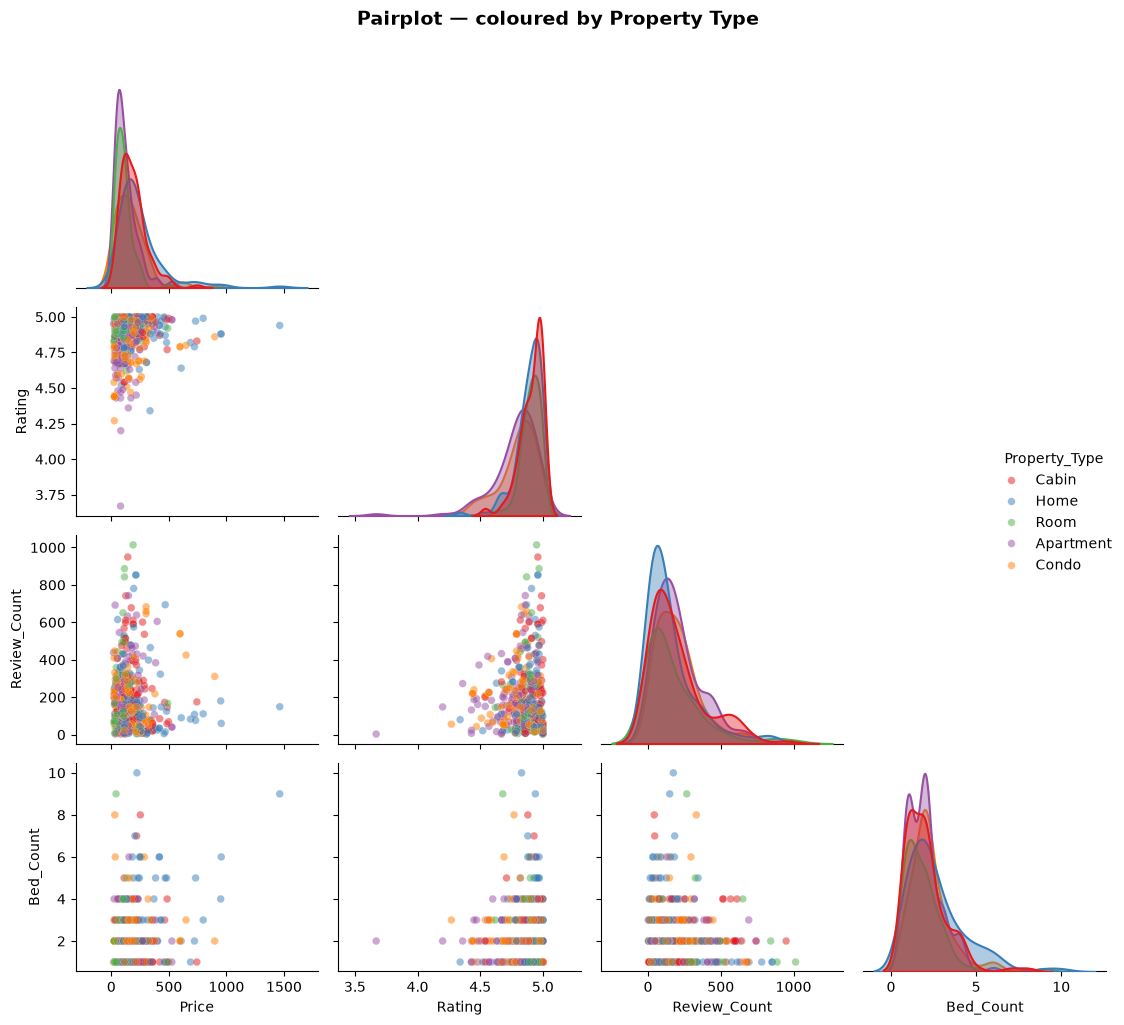

In [22]:
# ── 4.2  Core Pricing Metrics — coloured by Property Type ──────────────────
# Q: Do property types cluster differently?  Are Villas always in the
#    high-price, low-review-count corner?

multivariate_pairplot(
    df,
    num_cols=["Price", "Rating", "Review_Count", "Bed_Count"],
    hue="Property_Type",
    top_n_hue=5,
)

Pairplot — Price, Rating, Review_Count, Bed_Count coloured by Country

  Country = Unknown  (n = 249)
       Price  Rating  Review_Count  Bed_Count
mean  207.63    4.90        248.87        2.6
50%   175.00    4.93        172.00        2.0
std   133.15    0.11        229.86        1.6

  Country = US  (n = 109)
       Price  Rating  Review_Count  Bed_Count
mean  253.09    4.85        254.95       1.82
50%   219.00    4.87        209.00       2.00
std   190.89    0.15        220.75       1.14

  Country = Indonesia  (n = 109)
       Price  Rating  Review_Count  Bed_Count
mean  203.13    4.86        144.44       1.77
50%   167.00    4.89        104.00       1.00
std   152.01    0.11        157.38       1.34

  Country = Thailand  (n = 69)
       Price  Rating  Review_Count  Bed_Count
mean  101.20    4.85        130.17       2.07
50%    65.00    4.87         98.00       2.00
std   125.64    0.12         99.51       2.64



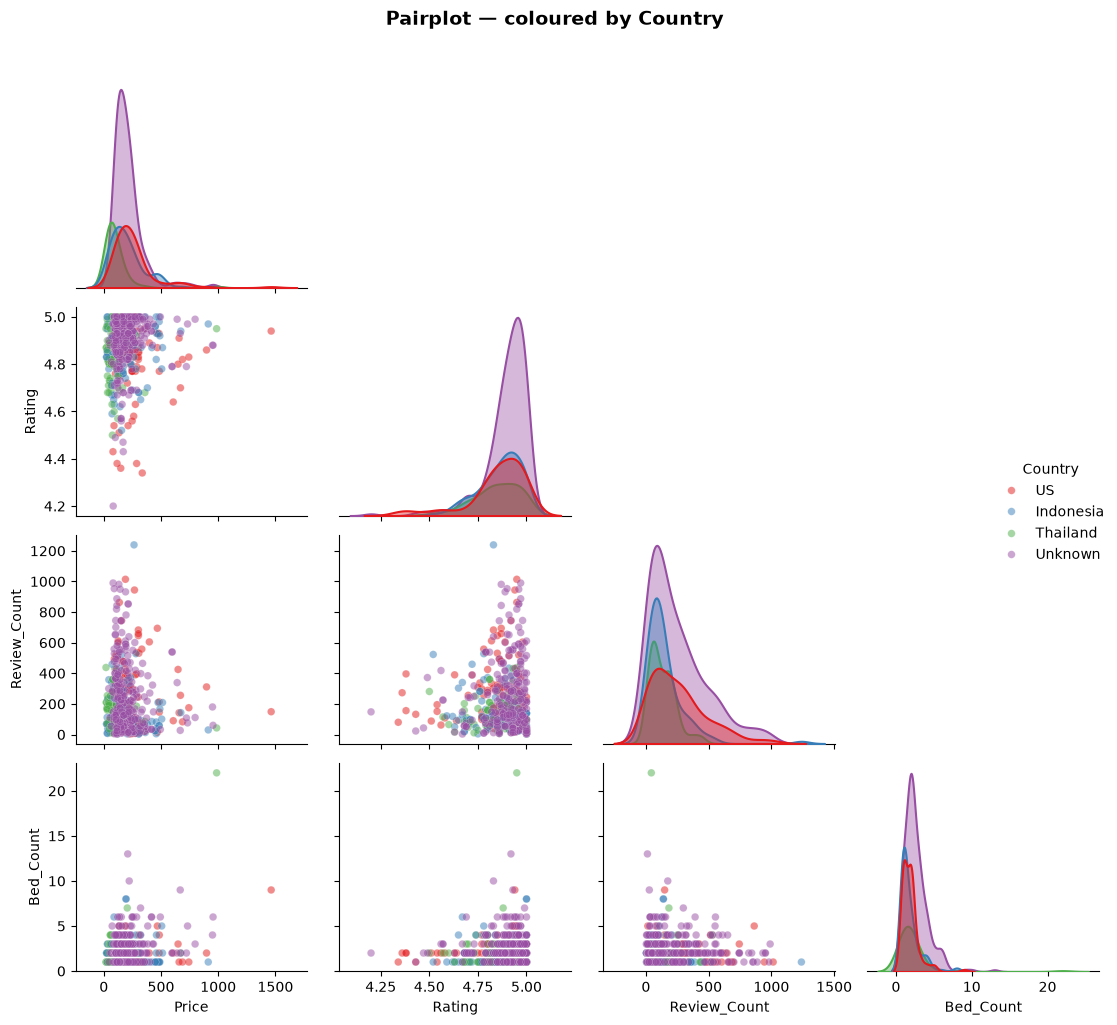

In [23]:
# ── 4.3  Core Pricing Metrics — coloured by Country ────────────────────────
# Q: Do US listings and Indonesian listings occupy completely separate
#    regions of the feature space?

multivariate_pairplot(
    df,
    num_cols=["Price", "Rating", "Review_Count", "Bed_Count"],
    hue="Country",
    top_n_hue=4,
)


Amenity Profile — Theme × [Has_Pool, Has_Hot_Tub, Has_Waterfront, Is_Near_Beach, Is_Mountain, Is_Rural]
          Has_Pool  Has_Hot_Tub  Has_Waterfront  Is_Near_Beach  Is_Mountain  Is_Rural
Theme                                                                                
General       12.3          2.5             0.0            0.6          0.9       6.5
Beach         17.3          1.9            33.7           77.9          1.9       1.4
Nature         4.9          6.0             2.7            4.4          7.7      13.7
Luxury        24.7          4.5             1.1           13.5          1.1       0.0
Romantic      13.0          5.6             1.9            9.3          0.0      14.8
Urban          2.9          0.0             0.0            0.0          2.9       5.9


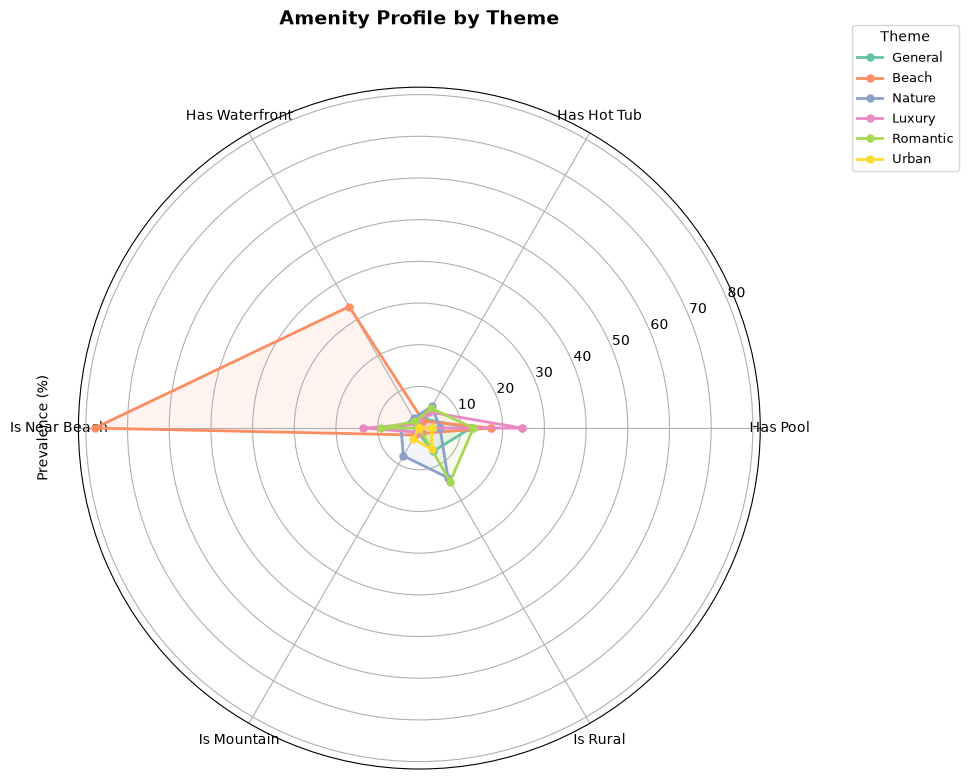

,Has_Pool,Has_Hot_Tub,Has_Waterfront,Is_Near_Beach,Is_Mountain,Is_Rural
Theme,,,,,,
General,12.345679,2.469136,0.000000,0.617284,0.925926,6.481481
Beach,17.307692,1.923077,33.653846,77.884615,1.923077,1.442308
Nature,4.945055,6.043956,2.747253,4.395604,7.692308,13.736264
Luxury,24.719101,4.494382,1.123596,13.483146,1.123596,0.000000
Romantic,12.962963,5.555556,1.851852,9.259259,0.000000,14.814815
Urban,2.941176,0.000000,0.000000,0.000000,2.941176,5.882353


In [24]:
# ── 5.1  Theme × All Location/Amenity Flags ────────────────────────────────
# Q: What % of Luxury, Nature, Beach, Romantic listings have
#    Pool / Hot Tub / Waterfront / Beach proximity / Mountain / Rural?

multivariate_amenity_profile(
    df,
    group_col="Theme",
    flag_cols=[
        "Has_Pool", "Has_Hot_Tub", "Has_Waterfront",
        "Is_Near_Beach", "Is_Mountain", "Is_Rural",
    ],
    top_n_groups=6,
)

Amenity Profile — Property_Type × [Has_Pool, Has_Hot_Tub, Has_Waterfront, Is_Near_Beach, Is_Mountain, Is_Rural]
               Has_Pool  Has_Hot_Tub  Has_Waterfront  Is_Near_Beach  Is_Mountain  Is_Rural
Property_Type                                                                             
Home               17.9          7.3             7.3           25.2          3.3       5.7
Apartment          19.3          0.0             7.6           30.3          0.8       1.7
Cabin               1.7         10.3             5.2            7.8          6.9      16.4
Condo               9.5          1.1            16.8           42.1          0.0       0.0
Room                6.0          0.0             1.2           13.3          0.0       0.0
Villa              40.3          3.2            17.7           30.6          0.0       3.2


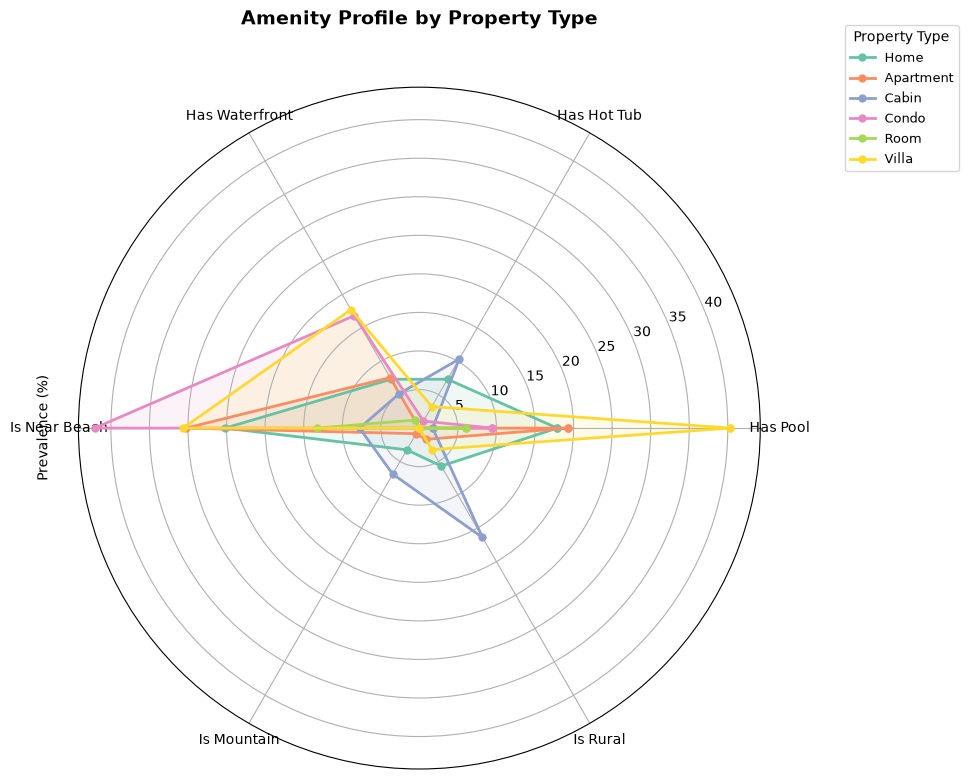

,Has_Pool,Has_Hot_Tub,Has_Waterfront,Is_Near_Beach,Is_Mountain,Is_Rural
Property_Type,,,,,,
Home,17.886179,7.317073,7.317073,25.203252,3.252033,5.691057
Apartment,19.327731,0.000000,7.563025,30.252101,0.840336,1.680672
Cabin,1.724138,10.344828,5.172414,7.758621,6.896552,16.379310
Condo,9.473684,1.052632,16.842105,42.105263,0.000000,0.000000
Room,6.024096,0.000000,1.204819,13.253012,0.000000,0.000000
Villa,40.322581,3.225806,17.741935,30.645161,0.000000,3.225806


In [25]:
# ── 5.2  Property Type × All Location/Amenity Flags ────────────────────────
# Q: Which property types are most likely to have a pool, be near a
#    beach, or be in the mountains?

multivariate_amenity_profile(
    df,
    group_col="Property_Type",
    flag_cols=[
        "Has_Pool", "Has_Hot_Tub", "Has_Waterfront",
        "Is_Near_Beach", "Is_Mountain", "Is_Rural",
    ],
    top_n_groups=6,
)


Amenity Profile — Country × [Has_Pool, Has_Hot_Tub, Has_Waterfront, Is_Near_Beach, Is_Mountain, Is_Rural]
           Has_Pool  Has_Hot_Tub  Has_Waterfront  Is_Near_Beach  Is_Mountain  Is_Rural
Country                                                                               
Unknown        10.8          5.6             6.4           23.1          3.2       6.8
US              7.0          9.6            12.2           31.3          6.1       9.6
Indonesia      25.5          0.9             6.4           21.8          0.0       0.9
Thailand       31.9          1.4            15.9           23.2          1.4       0.0
Canada          2.3          9.1            15.9            6.8          4.5      22.7
Mexico         10.0          0.0             5.0           35.0          2.5       0.0


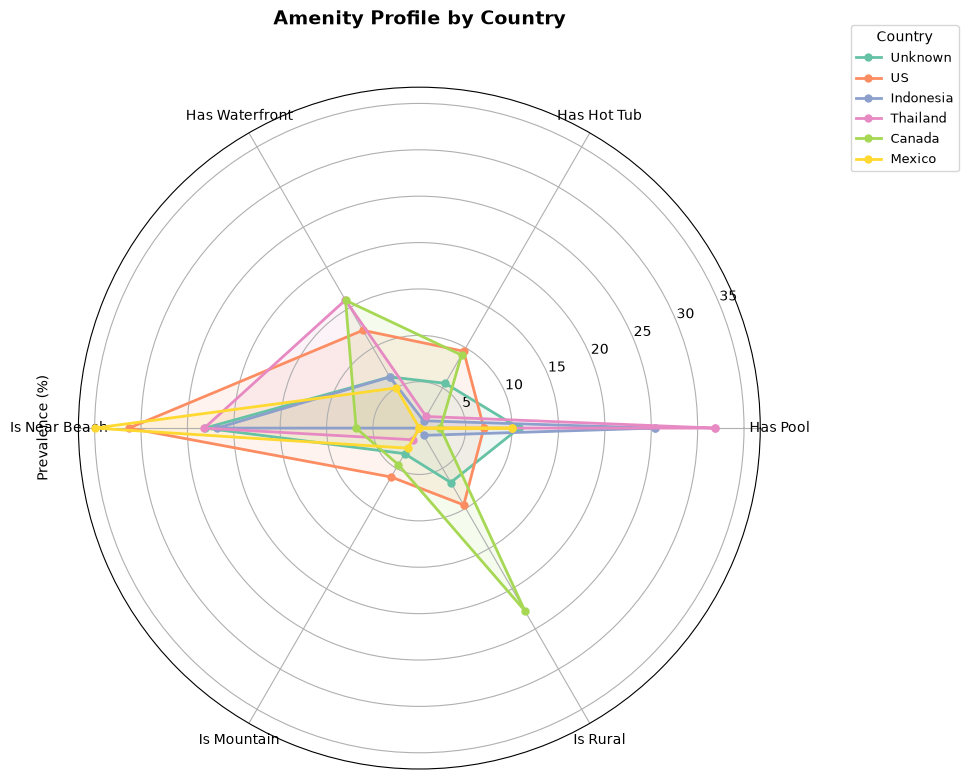

,Has_Pool,Has_Hot_Tub,Has_Waterfront,Is_Near_Beach,Is_Mountain,Is_Rural
Country,,,,,,
Unknown,10.756972,5.577689,6.374502,23.107570,3.187251,6.772908
US,6.956522,9.565217,12.173913,31.304348,6.086957,9.565217
Indonesia,25.454545,0.909091,6.363636,21.818182,0.000000,0.909091
Thailand,31.884058,1.449275,15.942029,23.188406,1.449275,0.000000
Canada,2.272727,9.090909,15.909091,6.818182,4.545455,22.727273
Mexico,10.000000,0.000000,5.000000,35.000000,2.500000,0.000000


In [26]:
# ── 5.3  Country × All Location/Amenity Flags ──────────────────────────────
# Q: Which countries have the highest prevalence of pools, beaches, etc.?
#    Does Indonesia's profile look completely different from the US?

multivariate_amenity_profile(
    df,
    group_col="Country",
    flag_cols=[
        "Has_Pool", "Has_Hot_Tub", "Has_Waterfront",
        "Is_Near_Beach", "Is_Mountain", "Is_Rural",
    ],
    top_n_groups=6,
)
